# EDA - Subastas Públicas de Inmuebles en España
Fuente: Portal de Subastas del BOE (subastas.boe.es)<br>
Período analizado: Octubre, Noviembre, Diciembre 2025

---
## Hipótesis

> *"Las subastas de inmuebles de organismos tributarios (AEAT y Recaudación Tributaria) en España entre octubre y diciembre 2025 se ofertan mayoritariamente por debajo del 50% de su valor de tasación"*

## Objetivo
Analizar el comportamiento de las subastas públicas de inmuebles 
en España: precios, descuentos sobre tasación, organismos 
convocantes y distribución geográfica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('./utils')

# Configuración de visualizaciones
from funciones import *
set_tema()

from bootcampviztools import *


 ==== Tema visual aplicado ====


# **1. VISUALIZACION**

### **1.1 Carga de los 3 dataset de subastas (Octubre, noviembre y diciembre) que está en la ruta './data/'**

In [2]:
df_oct = pd.read_csv('./data/subastas_inmuebles_oct2025.csv')
df_nov = pd.read_csv('./data/subastas_inmuebles_nov2025.csv')
df_dic = pd.read_csv('./data/subastas_inmuebles_dic2025.csv')

print(f'Octubre   : {len(df_oct):,} registros')
print(f'Noviembre : {len(df_nov):,} registros')
print(f'Diciembre : {len(df_dic):,} registros')
print(f'Total     : {len(df_oct) + len(df_nov) + len(df_dic):,} registros')

Octubre   : 1,671 registros
Noviembre : 1,518 registros
Diciembre : 1,537 registros
Total     : 4,726 registros


### **1.2 Concatenar los 3 dataset**

In [3]:
df = pd.concat([df_oct, df_nov, df_dic], ignore_index=True)

print(f'Dataset combinado: {df.shape}')
print(f'\n¿Hay duplicados?')
print(f'Filas duplicadas: {df.duplicated(subset="referencia").sum()}')

Dataset combinado: (4726, 23)

¿Hay duplicados?
Filas duplicadas: 0


In [4]:
#Primera 5 filas
df.head()

,referencia,num_lotes_listado,organismo,expediente,estado,fecha_conclusion_listado,descripcion,url_detalle,id_sub,referencia_det,...,fecha_conclusion,cantidad_reclamada_eur,lotes,anuncio_boe,valor_subasta_eur,tasacion_eur,puja_minima_eur,tramo_pujas_eur,deposito_eur,forma_adjudicacion
0,SUB-JA-2024-231148,1,JUZGADO 1 INSTANCIA 2 - LEON,0146/21,Pendiente de finalización y devolución de depó...,01/10/2025 a las 18:00:00,FINCA NÚMERO DIEZ.- Vivienda en la planta cuar...,https://subastas.boe.es/detalleSubasta.php?idS...,SUB-JA-2024-231148,SUB-JA-2024-231148,...,2025-10-01,38074.96,1,BOE-B-2025-31964,110887.98,0.0,NaN,NaN,5544.40,NaN
1,SUB-JA-2025-237883,1,UNIDAD SUBASTAS JUDICIALES MURCIA - MURCIA,0353/17,Finalizada y depósitos con reserva devueltos,01/10/2025 a las 18:00:00,Id. lote. 237883L1. Finca registral 37881. Pis...,https://subastas.boe.es/detalleSubasta.php?idS...,SUB-JA-2025-237883,SUB-JA-2025-237883,...,2025-10-01,56189.91,1,BOE-B-2025-31986,107904.68,0.0,NaN,2158.1,5395.23,NaN
2,SUB-JA-2025-242137,4,JUZGADO 1 INST E INSTRUCC. 1 - SOLSONA,0006/20,Finalizada y depósitos con reserva devueltos,01/10/2025 a las 18:00:00,"Subasta con varios lotes. Lote 1: URBANA, Parc...",https://subastas.boe.es/detalleSubasta.php?idS...,SUB-JA-2025-242137,SUB-JA-2025-242137,...,2025-10-01,112641.00,4,BOE-B-2025-31977,NaN,NaN,NaN,NaN,NaN,Separada para cada lote
3,SUB-JA-2025-244592,2,JUZGADO 1 INST E INSTRUCC. 1 - GANDESA,0442/20,Cancelada,NaN,Subasta con varios lotes. Lote 1: 1. URBANA. C...,https://subastas.boe.es/detalleSubasta.php?idS...,SUB-JA-2025-244592,SUB-JA-2025-244592,...,NaN,205737.80,2,BOE-B-2025-31954,NaN,NaN,NaN,NaN,NaN,Separada para cada lote
4,SUB-JA-2025-245672,1,Sección Civil e Instrucción TI Blanes. Plz.n 1...,0719/20,Finalizada y depósitos con reserva devueltos,01/10/2025 a las 18:00:00,URBANA: FINCA ESPECIAL. ENTIDAD NUMERO TRES.- ...,https://subastas.boe.es/detalleSubasta.php?idS...,SUB-JA-2025-245672,SUB-JA-2025-245672,...,2025-10-01,179629.82,1,BOE-B-2025-31945,259600.00,0.0,NaN,5192.0,12980.00,NaN


In [5]:
#Tipos de datos
df.info() #=====================aqui me quede

<class 'pandas.DataFrame'>
RangeIndex: 4726 entries, 0 to 4725
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   referencia                4726 non-null   str    
 1   num_lotes_listado         4726 non-null   int64  
 2   organismo                 4726 non-null   str    
 3   expediente                3360 non-null   str    
 4   estado                    4726 non-null   str    
 5   fecha_conclusion_listado  4364 non-null   str    
 6   descripcion               4653 non-null   str    
 7   url_detalle               4726 non-null   str    
 8   id_sub                    4726 non-null   str    
 9   referencia_det            4726 non-null   str    
 10  tipo_subasta              4726 non-null   str    
 11  cuenta_expediente         3360 non-null   str    
 12  fecha_inicio              4364 non-null   str    
 13  fecha_conclusion          4364 non-null   str    
 14  cantidad_reclamada_

In [6]:
#Estadísticas básicas
df.describe()

,num_lotes_listado,cantidad_reclamada_eur,lotes,valor_subasta_eur,tasacion_eur,puja_minima_eur,tramo_pujas_eur,deposito_eur
count,4726.000000,3.675000e+03,4726.000000,4.062000e+03,4.081000e+03,1.321000e+03,3465.000000,4.081000e+03
mean,1.826280,4.816601e+05,1.826280,2.527936e+05,1.042575e+05,5.205519e+04,4631.335076,1.371823e+04
std,4.901061,7.098250e+06,4.901061,9.245536e+05,6.142216e+05,3.647587e+05,18454.308898,4.773119e+04
min,1.000000,0.000000e+00,1.000000,0.000000e+00,0.000000e+00,1.000000e+00,5.830000,0.000000e+00
25%,1.000000,3.801988e+04,1.000000,4.001204e+04,0.000000e+00,6.258600e+02,600.000000,2.032850e+03
50%,1.000000,9.841809e+04,1.000000,1.168401e+05,0.000000e+00,2.436740e+03,2000.000000,5.993380e+03
75%,1.000000,1.944364e+05,1.000000,2.181989e+05,5.757713e+04,1.189674e+04,3733.750000,1.125000e+04
max,90.000000,4.175205e+08,90.000000,2.055066e+07,1.769050e+07,7.150000e+06,411013.120000,1.027533e+06


### **1.3 Analizando columnas duplicadas**

Durante la vista al dataset se observa que aparentemente hay columnas que tienen los mismos datos, sera necesario verificarlos.

In [7]:
# ====== Verificar 3 columnas posiblemente iguales ('referencia', 'id_sub', 'referencia_det') =======
print('=== REFERENCIAS ===')
print(f'¿referencia == id_sub?')
print(f'Iguales     : {(df["referencia"] == df["id_sub"]).sum()}')
print(f'Distintos   : {(df["referencia"] != df["id_sub"]).sum()}')
print(f'Nulos id_sub: {df["id_sub"].isna().sum()}')

print("---------------------------------")
print(f'¿referencia == referencia_det?')
print(f'Iguales             : {(df["referencia"] == df["referencia_det"]).sum()}')
print(f'Distintos           : {(df["referencia"] != df["referencia_det"]).sum()}')
print(f'Nulos referencia_det: {df["referencia_det"].isna().sum()}')

print("---------------------------------")
# Ver ejemplos de los 3 juntos
print('Muestra de las 3 columnas:')
df[['referencia', 'id_sub', 'referencia_det']].head(5)

=== REFERENCIAS ===
¿referencia == id_sub?
Iguales     : 4726
Distintos   : 0
Nulos id_sub: 0
---------------------------------
¿referencia == referencia_det?
Iguales             : 4726
Distintos           : 0
Nulos referencia_det: 0
---------------------------------
Muestra de las 3 columnas:


,referencia,id_sub,referencia_det
0,SUB-JA-2024-231148,SUB-JA-2024-231148,SUB-JA-2024-231148
1,SUB-JA-2025-237883,SUB-JA-2025-237883,SUB-JA-2025-237883
2,SUB-JA-2025-242137,SUB-JA-2025-242137,SUB-JA-2025-242137
3,SUB-JA-2025-244592,SUB-JA-2025-244592,SUB-JA-2025-244592
4,SUB-JA-2025-245672,SUB-JA-2025-245672,SUB-JA-2025-245672


In [8]:
# ====== Verificar 2 columnas posiblemente iguales ('num_lotes_listado', 'lotes')=======

print('=== LOTES ===')
print(f'¿num_lotes_listado == lotes?')
iguales = (df['num_lotes_listado'] == df['lotes']).sum()
distintos = (df['num_lotes_listado'] != df['lotes']).sum()
print(f'Iguales   : {iguales}')
print(f'Distintos : {distintos}')

print("---------------------------------")
# Ver ejemplos de los 2 juntos
print('Muestra de las 2 columnas:')
df[['num_lotes_listado', 'lotes']].head(5)


=== LOTES ===
¿num_lotes_listado == lotes?
Iguales   : 4726
Distintos : 0
---------------------------------
Muestra de las 2 columnas:


,num_lotes_listado,lotes
0,1,1
1,1,1
2,4,4
3,2,2
4,1,1


In [9]:
# ====== Verificar las 2 columnas posiblemente iguales ('fecha_conclusion_listado', 'fecha_conclusion')=======

print('=== FECHA CONCLUSION ===')
print(f'fecha_conclusion_listado == fecha_conclusion?')
iguales = (df['fecha_conclusion_listado'] == df['fecha_conclusion']).sum()
distintos = (df['fecha_conclusion_listado'] != df['fecha_conclusion']).sum()
print(f'Iguales   : {iguales}')
print(f'Distintos : {distintos}')

print("---------------------------------")
# Ver ejemplos de los 2 juntos
print('Muestra de las 2 columnas:')
df[['fecha_conclusion_listado', 'fecha_conclusion']].head(7)



=== FECHA CONCLUSION ===
fecha_conclusion_listado == fecha_conclusion?
Iguales   : 0
Distintos : 4726
---------------------------------
Muestra de las 2 columnas:


,fecha_conclusion_listado,fecha_conclusion
0,01/10/2025 a las 18:00:00,2025-10-01
1,01/10/2025 a las 18:00:00,2025-10-01
2,01/10/2025 a las 18:00:00,2025-10-01
3,NaN,NaN
4,01/10/2025 a las 18:00:00,2025-10-01
5,01/10/2025 a las 18:00:00,2025-10-01
6,01/10/2025 a las 18:00:00,2025-10-01


### **1.4 Analizando valores nulos**

In [10]:
#============ Nulos por columna =========
nulos = (df.isnull().sum() / len(df) * 100).round(2)
nulos = nulos[nulos > 0].sort_values(ascending=False)

print('Columnas con valores nulos (%):')
print(nulos.to_string())

Columnas con valores nulos (%):
forma_adjudicacion          86.35
puja_minima_eur             72.05
expediente                  28.90
cuenta_expediente           28.90
tramo_pujas_eur             26.68
cantidad_reclamada_eur      22.24
valor_subasta_eur           14.05
tasacion_eur                13.65
deposito_eur                13.65
fecha_conclusion_listado     7.66
fecha_inicio                 7.66
fecha_conclusion             7.66
descripcion                  1.54
anuncio_boe                  0.06


**Explicación de decisión de los valores nulos**

| Columna | Nulos % | Decisión | Motivo |
|---------|---------|----------|--------|
| ***forma_adjudicacion*** | ***85%*** |  ~~Eliminar~~ | ***Solo aparece en subastas con varios lotes*** |
| puja_minima_eur | 78% |  Conservar | "Sin puja mínima" es información válida |
| tramo_pujas_eur | 29% |  Conservar | Útil para análisis económico |
| ***expediente*** | ***23%*** |  ~~Eliminar~~ | ***Solo judicial, no aporta al análisis*** |
| ***cuenta_expediente*** | ***23%*** |  ~~Eliminar~~ | ***Solo judicial, no aporta al análisis*** |
| cantidad_reclamada_eur | 16% |  Conservar | Útil para comparar judicial vs AEAT |
| valor_subasta_eur | 15% |  Conservar | Campo clave para hipótesis |
| tasacion_eur | 15% |  Conservar | Campo clave para hipótesis |
| deposito_eur | 15% |  Conservar | Útil para análisis económico |
| fecha_conclusion | 7% |  Conservar | Campo temporal importante |
| fecha_inicio | 7% |  Conservar | Campo temporal importante |
| descripcion | 3% |  Conservar | Descripción del bien |

### **1.5 Aplicando limpieza** 

* Durante la verificación de posibles columnas duplicadas, se encontraron **3** columnas duplicadas :

        'id_sub','referencia_det','num_lotes_listado'

* Se identificaron **3** columnas que no aportan al análisis:

        'url_detalle','anuncio_boe', 'cantidad_reclamada_eur'

* Se identificaron **3** columnas con registros nulos que no aportan al análisis: 

        'forma_adjudicacion' - con 85% registros nulos  
        'expediente'         - 23% registros
        'cuenta_expediente'  - 23% registros

* Las fechas estaban en formato tipo 'String' y se decide convertir a Datetime


In [11]:
# Llamada a la funcion que elimina las 8 columnas
# Convierte fechas a datetime

df, cols_eliminadas = limpiar_dataframe(df)

In [12]:
#======= Verificando =====================
print(f'===== Limpieza aplicada =====')
print(f'Colummas eliminadas:\n{cols_eliminadas}')
print(f'Shape actual:{df.shape} ')
print(f'\n ===== Columnas restantes: =====')
df.info()
#for i, col in enumerate(df.columns):
#    print(f'  {i:2d}. {col}')


===== Limpieza aplicada =====
Colummas eliminadas:
['id_sub', 'referencia_det', 'num_lotes_listado', 'url_detalle', 'anuncio_boe', 'cantidad_reclamada_eur', 'descripcion', 'fecha_conclusion_listado', 'forma_adjudicacion', 'expediente', 'cuenta_expediente']
Shape actual:(4726, 12) 

 ===== Columnas restantes: =====
<class 'pandas.DataFrame'>
RangeIndex: 4726 entries, 0 to 4725
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   referencia         4726 non-null   str           
 1   organismo          4726 non-null   str           
 2   estado             4726 non-null   str           
 3   tipo_subasta       4726 non-null   str           
 4   fecha_inicio       4364 non-null   datetime64[us]
 5   fecha_conclusion   4364 non-null   datetime64[us]
 6   lotes              4726 non-null   int64         
 7   valor_subasta_eur  4062 non-null   float64       
 8   tasacion_eur       4081 non-null 

### **1.7 Calculando descuento_pct**
Mide cuánto por debajo de la tasación sale el precio de subasta.<br>

**- Cálculo:** Generalmente se calcula como:<br>
        **descuento_pct = (tasacion_eur - valor_subasta_eur) / tasacion_eur * 100**

**-Ejemplo:** <br>
tasacion_eur      = 100.000 €<br>
valor_subasta_eur =  60.000 €<br>
descuento_pct = (100.000 - 60.000) / 100.000 * 100 = 40%<br>

--> El inmueble sale a subasta con un 40% de descuento sobre su valor de mercado.




In [13]:
# Llamada a la función y asignar los resultados
df_limpio, mascara_calculo = calcular_pct(df)

In [14]:
# ===== Verificando ======
print(f'descuento_pct calculado')
print(f'Con descuento  : {mascara_calculo.sum()}')
print(f'Sin descuento  : {df["descuento_pct"].isna().sum()}')

descuento_pct calculado
Con descuento  : 1969
Sin descuento  : 2757


### **1.8 Calculando duración de la subasta**

In [15]:
# Cuántos días duró cada subasta
calcular_duracion_dias(df)
print(f'==== duracion_dias calculado ====')

==== duracion_dias calculado ====


### **1.9 Resumen del dataset**

In [16]:
resumen_dataset(df)

===== RESUMEN DEL DATASET =====
Filas   : 4,726
Columnas: 14

 Tipos de subasta:
tipo_subasta
JUDICIAL EN VÍA DE APREMIO    3147
AGENCIA TRIBUTARIA            1012
RECAUDACIÓN TRIBUTARIA         312
JUDICIAL VOLUNTARIA            149
JUDICIAL CONCURSAL              64
OTRAS SUBASTAS NOTARIALES       20
NOTARIAL HIPOTECARIA            15
ADMINISTRATIVA GENERAL           7

  Descuento sobre tasación (%):
count       1969.00
mean        -506.28
std        22616.44
min     -1003515.83
25%            0.00
50%            0.00
75%           17.37
max           99.00
Name: descuento_pct, dtype: float64
---------------------------


In [17]:
#=========== Se evidencia datos negativos en descuento_pct ======= 
# Ver los casos extremos
print('=== VALORES EXTRAÑOS ===')
print('\nTop 5 descuentos más negativos:')
print(df[['referencia', 'tipo_subasta','tasacion_eur', 'valor_subasta_eur', 'descuento_pct']]
      .sort_values('descuento_pct')
      .head(5)
      .to_string())

print('\nTop 5 descuentos más altos:')
print(df[['referencia', 'tipo_subasta', 'tasacion_eur', 'valor_subasta_eur', 'descuento_pct']]
      .sort_values('descuento_pct', ascending=False)
      .head(5)
      .to_string())

print('\n¿Cuántos tienen tasacion_eur == 0?')
print(df[df['tasacion_eur'] == 0]['tasacion_eur'].count())

print('¿Cuántos tienen descuento negativo?')
print((df['descuento_pct'] < 0).sum())

print('¿Cuántos tienen descuento == 0?')
print((df['descuento_pct'] == 0).sum())

=== VALORES EXTRAÑOS ===

Top 5 descuentos más negativos:
              referencia                tipo_subasta  tasacion_eur  valor_subasta_eur  descuento_pct
4431  SUB-JA-2025-254826  JUDICIAL EN VÍA DE APREMIO        120.00         1204339.00    -1003515.83
3412  SUB-JV-2025-253747         JUDICIAL VOLUNTARIA     182794.64        18279464.00       -9900.00
3007  SUB-JA-2025-253412  JUDICIAL EN VÍA DE APREMIO      17821.40          178214.40        -900.00
3031  SUB-JA-2025-253510  JUDICIAL EN VÍA DE APREMIO      54018.01           93911.34         -73.85
1963  SUB-JA-2025-249929  JUDICIAL EN VÍA DE APREMIO      88919.57          120528.88         -35.55

Top 5 descuentos más altos:
                     referencia                tipo_subasta  tasacion_eur  valor_subasta_eur  descuento_pct
764          SUB-JA-2025-251488  JUDICIAL EN VÍA DE APREMIO    9910000.00           99100.00          99.00
4105  SUB-AT-2025-25R5086001073          AGENCIA TRIBUTARIA      21067.72             244.9

In [18]:
print('=== DIAGNÓSTICO TASACION ===')
print(f'tasacion_eur == 0: {(df["tasacion_eur"] == 0).sum()}')
print(f'tasacion_eur nula: {df["tasacion_eur"].isna().sum()}')
print(f'tasacion_eur > 0 : {(df["tasacion_eur"] > 0).sum()}')

print('\n=== DIAGNÓSTICO VALOR SUBASTA ===')
print(f'valor_subasta nulo: {df["valor_subasta_eur"].isna().sum()}')
print(f'valor_subasta == 0: {(df["valor_subasta_eur"] == 0).sum()}')
print(f'valor_subasta > 0 : {(df["valor_subasta_eur"] > 0).sum()}')

print('\n=== POR TIPO DE SUBASTA ===')
print(df.groupby('tipo_subasta')[['tasacion_eur', 'valor_subasta_eur']].agg(
    lambda x: x.isna().sum()
).rename(columns={'tasacion_eur': 'nulos_tasacion', 
                  'valor_subasta_eur': 'nulos_valor'}))

=== DIAGNÓSTICO TASACION ===
tasacion_eur == 0: 2093
tasacion_eur nula: 645
tasacion_eur > 0 : 1988

=== DIAGNÓSTICO VALOR SUBASTA ===
valor_subasta nulo: 664
valor_subasta == 0: 1
valor_subasta > 0 : 4061

=== POR TIPO DE SUBASTA ===
                            nulos_tasacion  nulos_valor
tipo_subasta                                           
ADMINISTRATIVA GENERAL                   0            0
AGENCIA TRIBUTARIA                       0            0
JUDICIAL CONCURSAL                      21           21
JUDICIAL EN VÍA DE APREMIO             548          548
JUDICIAL VOLUNTARIA                     21           21
NOTARIAL HIPOTECARIA                     3           12
OTRAS SUBASTAS NOTARIALES                4           14
RECAUDACIÓN TRIBUTARIA                  48           48


In [19]:
# ============= Volver a cargar dataset para verificar algunos datos en la web ====
df_verif = pd.concat([df_oct, df_nov, df_dic], ignore_index=True)
#df_verif.info()

# ======== Ver la URL de uno de estos registros en el df original =======
print(df_verif[df_verif['referencia'] == 'SUB-JA-2025-254826']['url_detalle'].values[0])
print(df_verif[df_verif['referencia'] == 'SUB-JV-2025-253747']['url_detalle'].values[0])
print(df_verif[df_verif['referencia'] == 'SUB-JA-2025-253412']['url_detalle'].values[0])

https://subastas.boe.es/detalleSubasta.php?idSub=SUB-JA-2025-254826&idBus=b1dsZHcyK2F3Z2VwRFVqaXQ1OGVPbGZZWnlDUzY0ekcvQTAzTDNNSks0RTJWL0h4UXRTRW1hdnlIRDJuMzJjMVgxYks0MUpxak5iWWpQNnZGaGhSMGVmUTNyUnpkS0JvWUtiSm56a1IxcjdYQXRpY2E2dHVFNnNtMXNoWDFvak1EeXhZVTZNQ3JCUlk0WVptemtmbHlLT21sbkF0TVpFOHRXYnp3Lzhhc0xzVmREWWNzVllPekhpTFp0NjRzQXJIaFdLY3h4WjNsc0tCR2JBOXN1d01lWXp0aG1iUjZTWTlmNkF3bHdGSFRRa2tCeG5WZnJFUzl2cmljMldsd1Q5VE1MWFJqVmF5VElCM2xud2s1UE5tckVPLzNHVjV1Vy8wbVpMdnpCRUdWeGxrUHFMODlmOVZVN09pVVEvcldOZGI,-1200-50
https://subastas.boe.es/detalleSubasta.php?idSub=SUB-JV-2025-253747&idBus=b1dsZHcyK2F3Z2VwRFVqaXQ1OGVPbGZZWnlDUzY0ekcvQTAzTDNNSks0RTJWL0h4UXRTRW1hdnlIRDJuMzJjMVgxYks0MUpxak5iWWpQNnZGaGhSMGVmUTNyUnpkS0JvWUtiSm56a1IxcjdYQXRpY2E2dHVFNnNtMXNoWDFvak1EeXhZVTZNQ3JCUlk0WVptemtmbHlLT21sbkF0TVpFOHRXYnp3Lzhhc0xzVmREWWNzVllPekhpTFp0NjRzQXJIaFdLY3h4WjNsc0tCR2JBOXN1d01lWXp0aG1iUjZTWTlmNkF3bHdGSFRRa2tCeG5WZnJFUzl2cmljMldsd1Q5VE1MWFJqVmF5VElCM2xud2s1UE5tckVPLzNHVjV1Vy8wbVpMdnpCRUdWeGxrUHFMODlmOVZVN09


### **1.9 Decisión sobre el dataset de análisis**

Durante la exploración se identificaron tres problemas en los datos:

**Problema 1 — Datos de origen incompletos**
Del totla 4,726 registros:
- 2,093 tienen ***tasacion_eur = 0***
- 645 tienen ***tasacion_eur** nula
- Solo 1,988 tienen tasación válida > 0

Verificando directamente en el portal del BOE se confirmó que estos valores provienen del origen los juzgados no siempre registran la tasación correctamente.

**Problema 2 — Anomalías en los datos**
Se detectaron registros donde ***valor_subasta_eur*** supera a ***tasacion_eur***, lo cual es económicamente incoherente. Verificando en el BOE se confirmó que son errores de origen:

- SUB-JA-2025-254826: Tasación = 120€, Valor subasta = 1.204.339€
- SUB-JA-2025-253747: Tasación = 182.794,64€, Valor subasta = 18.279.464.00€

**Problema 3 — Concentración de datos completos**
Al analizar nulos por tipo de subasta, se observó que los organismos tributarios ***(AEAT y Recaudación Tributaria)*** son los únicos con datos completos y coherentes:

| Tipo de subasta | Registros | Nulos tasación | Nulos valor subasta |
|----------------|-----------|---------------|-------------------|
| AGENCIA TRIBUTARIA | 1,012 | 0 | 0 |
| RECAUDACIÓN TRIBUTARIA | 312 | 48 | 48 |
| JUDICIAL EN VÍA DE APREMIO | 3,147 | 548 | 548 |
| JUDICIAL VOLUNTARIA | 149 | 21 | 21 |
| JUDICIAL CONCURSAL | 64 | 21 | 21 |

**Decisión:**
Se trabajará con los registros de organismos tributarios ***(AEAT y Recaudación Tributaria)*** con datos económicos completos y coherentes. Esto representa una muestra representativa y fiable para contrastar la hipótesis planteada.

### **1.10 Filtrar regitros con valores coherentes**
Condiciones para un registro válido:

1. Tipo de subasta (AGENCIA TRIBUTARIA, RECAUDACIÓN TRIBUTARIA)
2. tasacion_eur y valor_subasta_eur no nulos
3. tasacion_eur > valor_subasta_eur (la tasación debe ser mayor)

In [20]:
df_analisis = filtrar_tributarios(df)

print(f'Registros originales: {len(df)}')
print(f'Registros análisis  : {len(df_analisis)}')

Registros originales: 4726
Registros análisis  : 498


Se trabajará con los 498 registros de organismos tributarios **(419 de AEAT y 79 de Recaudación Tributaria)** con datos económicos completos y coherentes:
Esto representa el **10.5%** del dataset original pero es la muestra más fiable y representativa para contrastar la hipótesis.

In [21]:
df_analisis.info()

<class 'pandas.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   referencia         498 non-null    str           
 1   organismo          498 non-null    str           
 2   estado             498 non-null    str           
 3   tipo_subasta       498 non-null    str           
 4   fecha_inicio       470 non-null    datetime64[us]
 5   fecha_conclusion   470 non-null    datetime64[us]
 6   lotes              498 non-null    int64         
 7   valor_subasta_eur  498 non-null    float64       
 8   tasacion_eur       498 non-null    float64       
 9   puja_minima_eur    397 non-null    float64       
 10  tramo_pujas_eur    498 non-null    float64       
 11  deposito_eur       498 non-null    float64       
 12  descuento_pct      498 non-null    float64       
 13  duracion_dias      470 non-null    float64       
dtypes: datetime64[us](2),

### **1.11 Tratamiento de valores nulos**

In [22]:
# ¿Por qué faltan las fechas? (fecha_inicio, fecha_conclusion, duracion_dias)
sin_fechas = df_analisis[df_analisis['fecha_inicio'].isna()]

print(f'Registros sin fechas: {len(sin_fechas)}')
print('--------------------------')
print(f'Tipo de subasta:')
print(sin_fechas['tipo_subasta'].value_counts())
print('--------------------------')
print(f'Estado:')
print(sin_fechas['estado'].value_counts())
print('--------------------------')
print(f'\nMuestra de referencias:')
print(sin_fechas['referencia'].head(5).to_string())

Registros sin fechas: 28
--------------------------
Tipo de subasta:
tipo_subasta
AGENCIA TRIBUTARIA        16
RECAUDACIÓN TRIBUTARIA    12
Name: count, dtype: int64
--------------------------
Estado:
estado
Cancelada    28
Name: count, dtype: int64
--------------------------

Muestra de referencias:
4     SUB-AT-2025-25R2986001166
19    SUB-RC-2025-4690000146921
50    SUB-RC-2025-0601100103005
52    SUB-RC-2025-0601100103009
53    SUB-AT-2025-25R4186001439


**Decision de valores nulos**

| Columna | Nulos | Motivo | Decisión |
|---------|-------|--------|----------|
| fecha_inicio | 28 | Subastas canceladas | Conservar — el nulo es informativo |
| fecha_conclusion | 28 | Subastas canceladas | Conservar — el nulo es informativo |
| duracion_dias | 28 | Subastas canceladas | Conservar — no aplica para canceladas |
| puja_minima_eur | 101 | "Sin puja mínima" | Conservar — es información válida |

### **1.12 Revisando Outliers**

### descuento_pct
Outliers por encima del **68%** son subastas con descuentos muy elevados, posiblemente con cargas registrales altas.

**Decisión:** Se conservan porque son informativos para el análisis

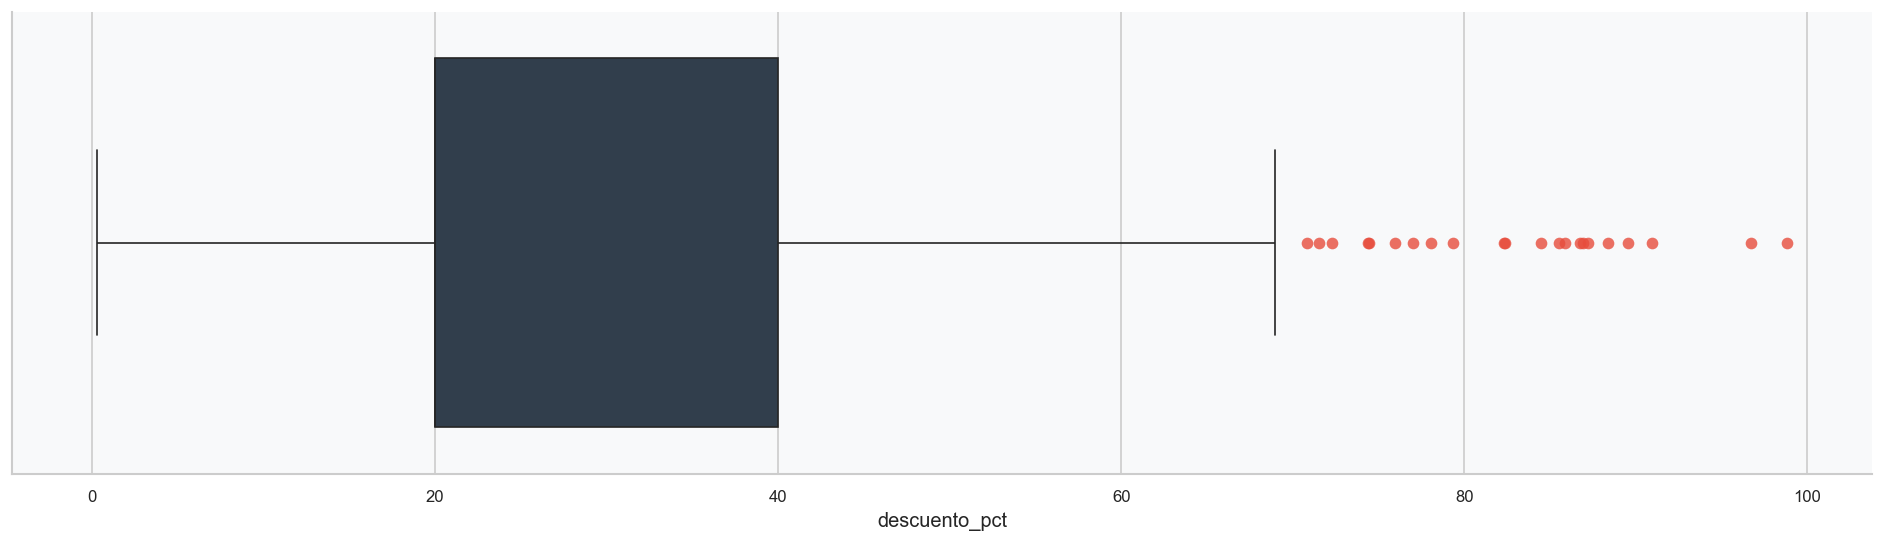

In [23]:
# Boxplots de todas las variables numéricas para ver outliers claramente
plt.figure(figsize=(20,5))
flierprops = dict(marker='o', markerfacecolor = color_secundario, markersize=7, markeredgecolor='none', alpha=0.8)
retornado = sns.boxplot(df_analisis["descuento_pct"], color= color_principal, orient= 'h', flierprops= flierprops)

### valor_subasta_eur y tasacion_eur
- Un outlier extremo visible por encima de 1M€ 
- Corresponde a inmuebles de alto valor (locales comerciales, naves industriales)

**Decisión:** Se conservan son subastas reales y válidas

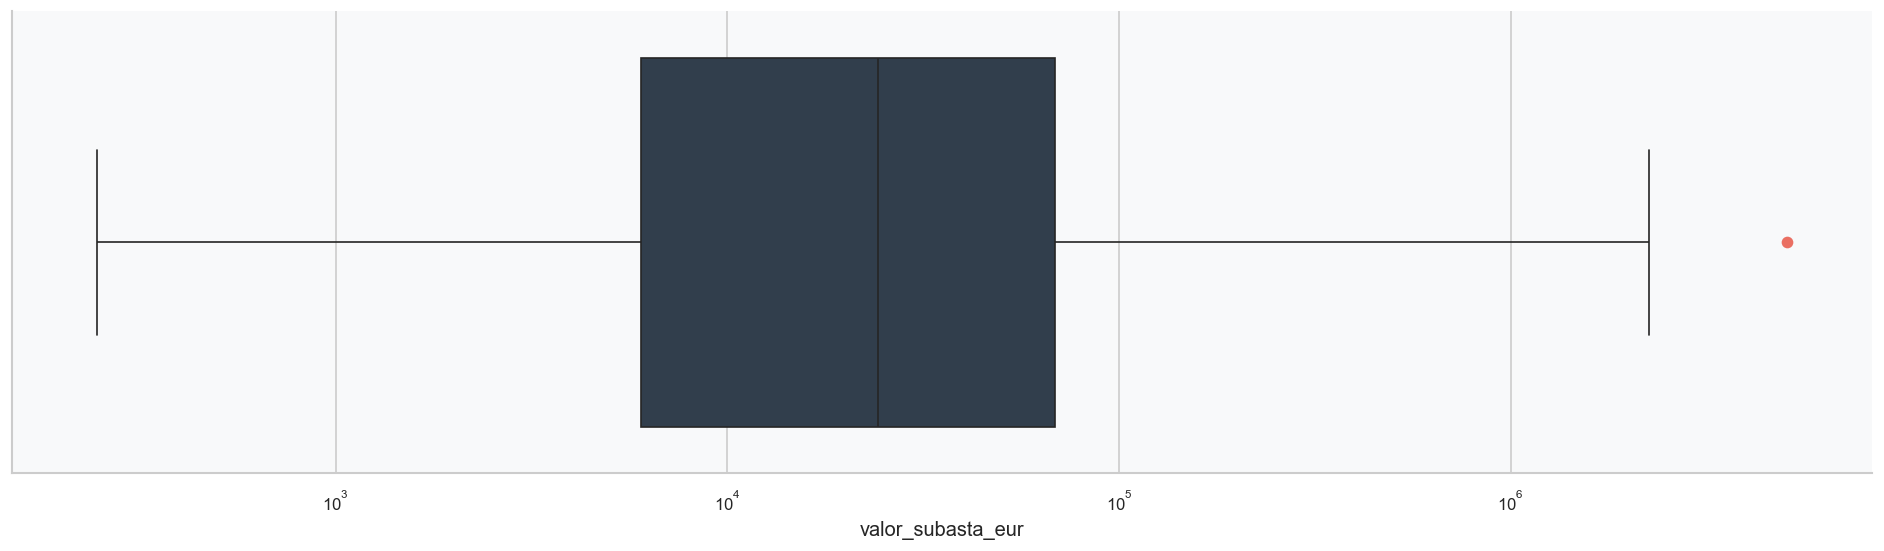

In [24]:
plt.figure(figsize=(20,5))
retornado = sns.boxplot(df_analisis["valor_subasta_eur"], color= color_principal, orient= 'h', log_scale= True, flierprops= flierprops)


In [25]:
df_analisis.sort_values('valor_subasta_eur', ascending= False).head(1)

,referencia,organismo,estado,tipo_subasta,fecha_inicio,fecha_conclusion,lotes,valor_subasta_eur,tasacion_eur,puja_minima_eur,tramo_pujas_eur,deposito_eur,descuento_pct,duracion_dias
490,SUB-RC-2025-1700100125009,XALOC - Xarxa Local de Municipis de la Diputac...,Finalizada y depósitos con reserva devueltos,RECAUDACIÓN TRIBUTARIA,2025-12-09,2025-12-29,1,5089385.47,5878200.0,508938.55,1000.0,254469.27,13.42,20.0


In [26]:
# ======== Ver la URL de uno de estos registros en el df original =======
print(df_verif[df_verif['referencia'] == 'SUB-RC-2025-1700100125009']['url_detalle'].values[0])

https://subastas.boe.es/detalleSubasta.php?idSub=SUB-RC-2025-1700100125009&idBus=b1dsZHcyK2F3Z2VwRFVqaXQ1OGVPbGZZWnlDUzY0ekcvQTAzTDNNSks0RTJWL0h4UXRTRW1hdnlIRDJuMzJjMVgxYks0MUpxak5iWWpQNnZGaGhSMGVmUTNyUnpkS0JvWUtiSm56a1IxcjdYQXRpY2E2dHVFNnNtMXNoWDFvak1EeXhZVTZNQ3JCUlk0WVptemtmbHlLT21sbkF0TVpFOHRXYnp3Lzhhc0xzVmREWWNzVllPekhpTFp0NjRzQXJIaFdLY3h4WjNsc0tCR2JBOXN1d01lWXp0aG1iUjZTWTlmNkF3bHdGSFRRa2tCeG5WZnJFUzl2cmljMldsd1Q5VE1MWFJqVmF5VElCM2xud2s1UE5tckVPLzNHVjV1Vy8wbVpMdnpCRUdWeGxrUHFMODlmOVZVN09pVVEvcldOZGI,-1450-50


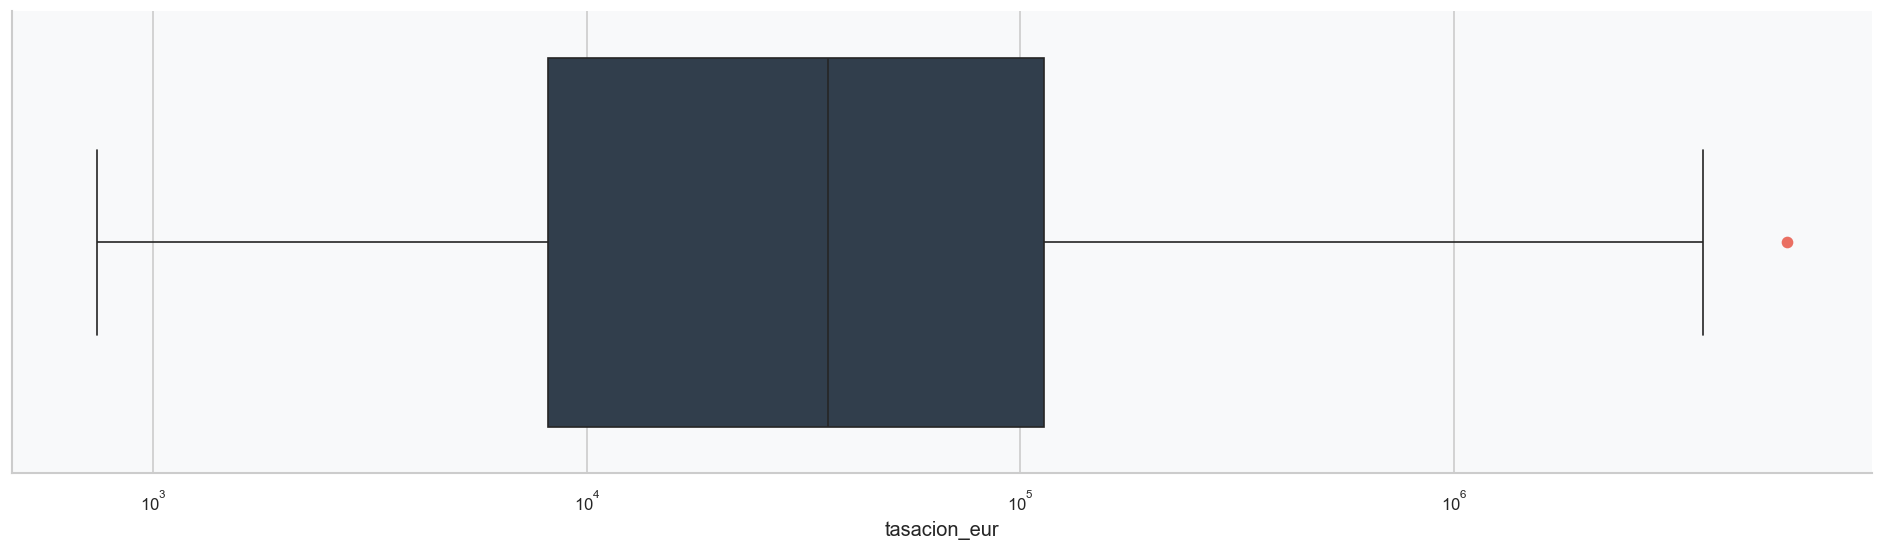

In [27]:
plt.figure(figsize=(20,5))
retornado = sns.boxplot(df_analisis["tasacion_eur"], color= color_principal, orient= 'h',  log_scale= True, flierprops = flierprops)

In [28]:
df_analisis.sort_values('tasacion_eur', ascending= False).head(1)

,referencia,organismo,estado,tipo_subasta,fecha_inicio,fecha_conclusion,lotes,valor_subasta_eur,tasacion_eur,puja_minima_eur,tramo_pujas_eur,deposito_eur,descuento_pct,duracion_dias
490,SUB-RC-2025-1700100125009,XALOC - Xarxa Local de Municipis de la Diputac...,Finalizada y depósitos con reserva devueltos,RECAUDACIÓN TRIBUTARIA,2025-12-09,2025-12-29,1,5089385.47,5878200.0,508938.55,1000.0,254469.27,13.42,20.0


### puja_minima_eur

- Un outlier por encima de 100.000€
- Inmueble de alto valor con puja mínima elevada

**Decisión:** Se conserva

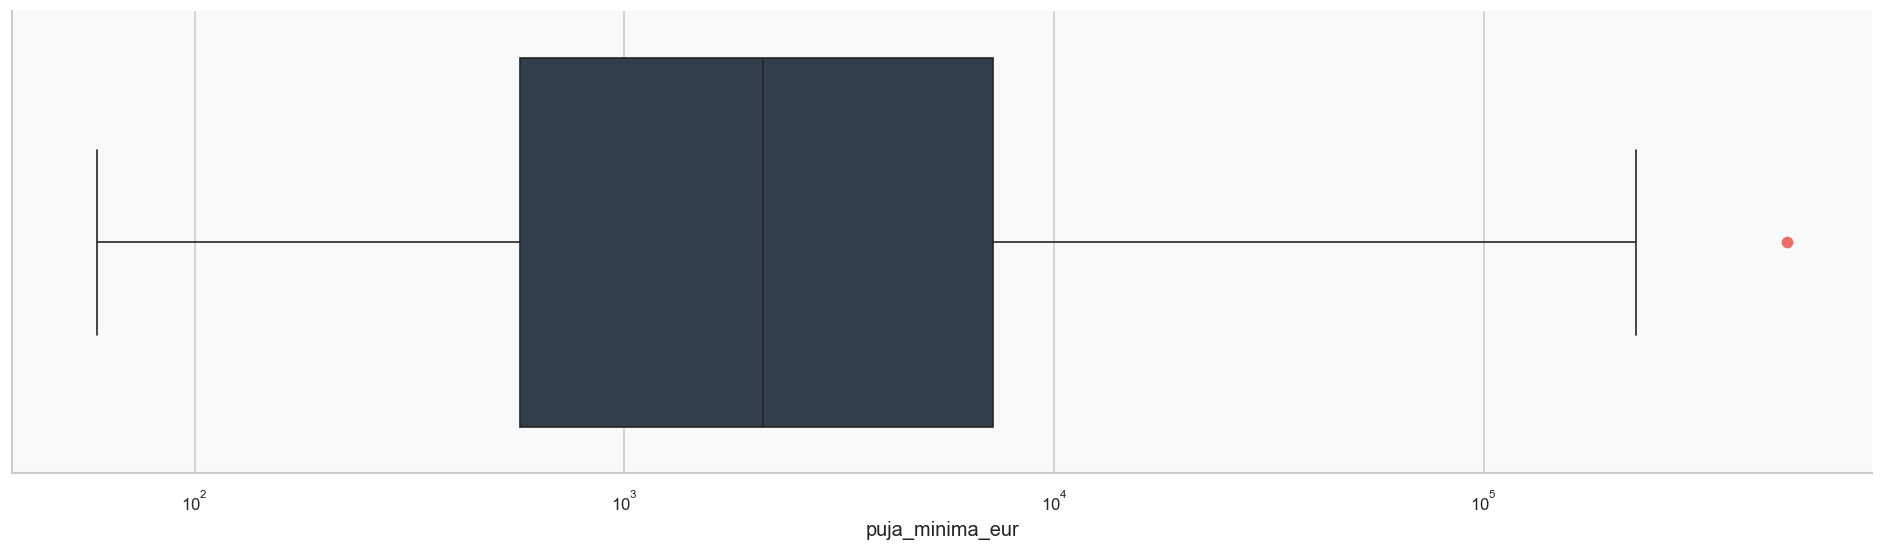

In [29]:
plt.figure(figsize=(20,5))
retornado = sns.boxplot(df_analisis["puja_minima_eur"], color= color_principal, orient= 'h', log_scale= True, flierprops = flierprops)

In [30]:
df_analisis.sort_values('puja_minima_eur', ascending= False).head(1)

,referencia,organismo,estado,tipo_subasta,fecha_inicio,fecha_conclusion,lotes,valor_subasta_eur,tasacion_eur,puja_minima_eur,tramo_pujas_eur,deposito_eur,descuento_pct,duracion_dias
490,SUB-RC-2025-1700100125009,XALOC - Xarxa Local de Municipis de la Diputac...,Finalizada y depósitos con reserva devueltos,RECAUDACIÓN TRIBUTARIA,2025-12-09,2025-12-29,1,5089385.47,5878200.0,508938.55,1000.0,254469.27,13.42,20.0


### tramo_pujas_eur

- 4 outliers visibles entre 4.000€ y 10.000€
- Inmuebles de mayor valor requieren tramos más altos

**Decisión:** Se conservan

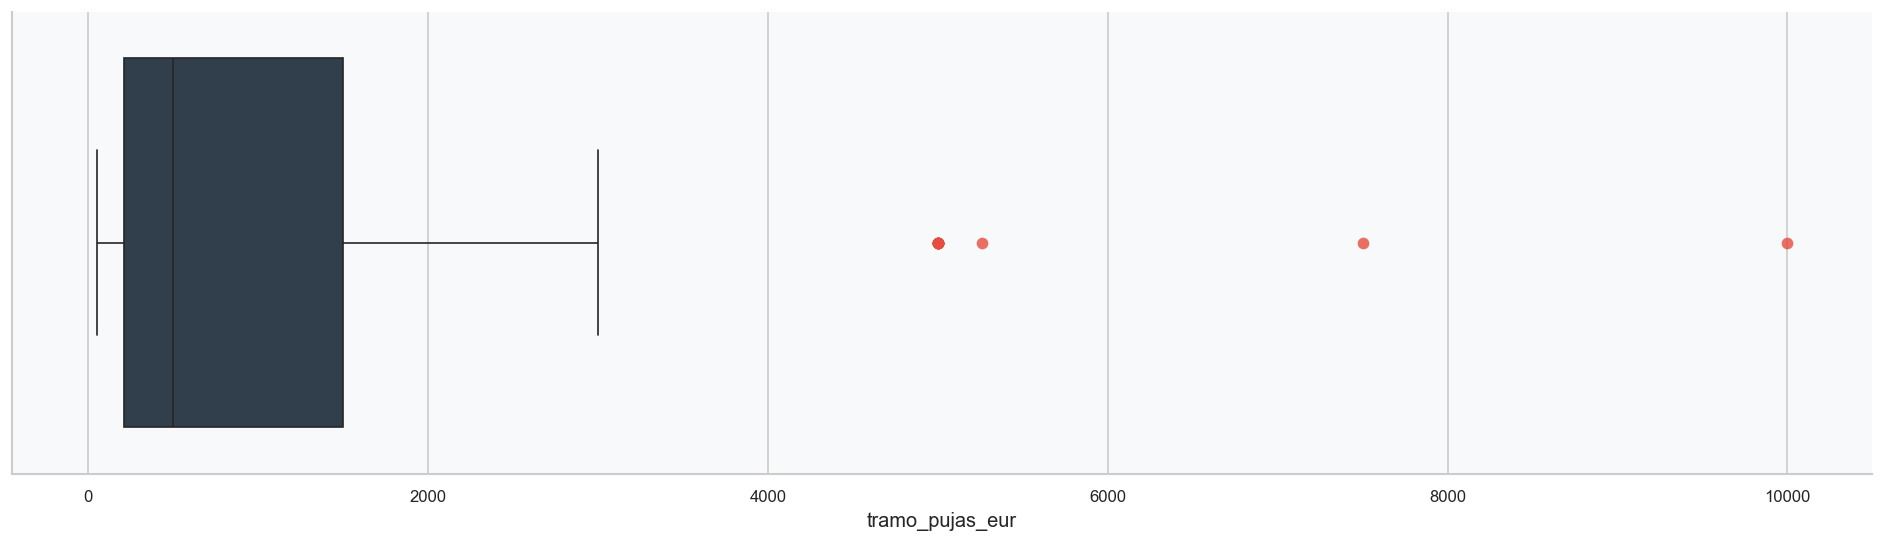

In [31]:
plt.figure(figsize=(20,5))
retornado = sns.boxplot(df_analisis["tramo_pujas_eur"], color= color_principal, orient= 'h', flierprops= flierprops)

### deposito_eur

- Un outlier extremo por encima de 100.000€
- Corresponde al mismo inmueble de alto valor

**Decisión:** Se conserva, el depósito es el 5% del valor subasta

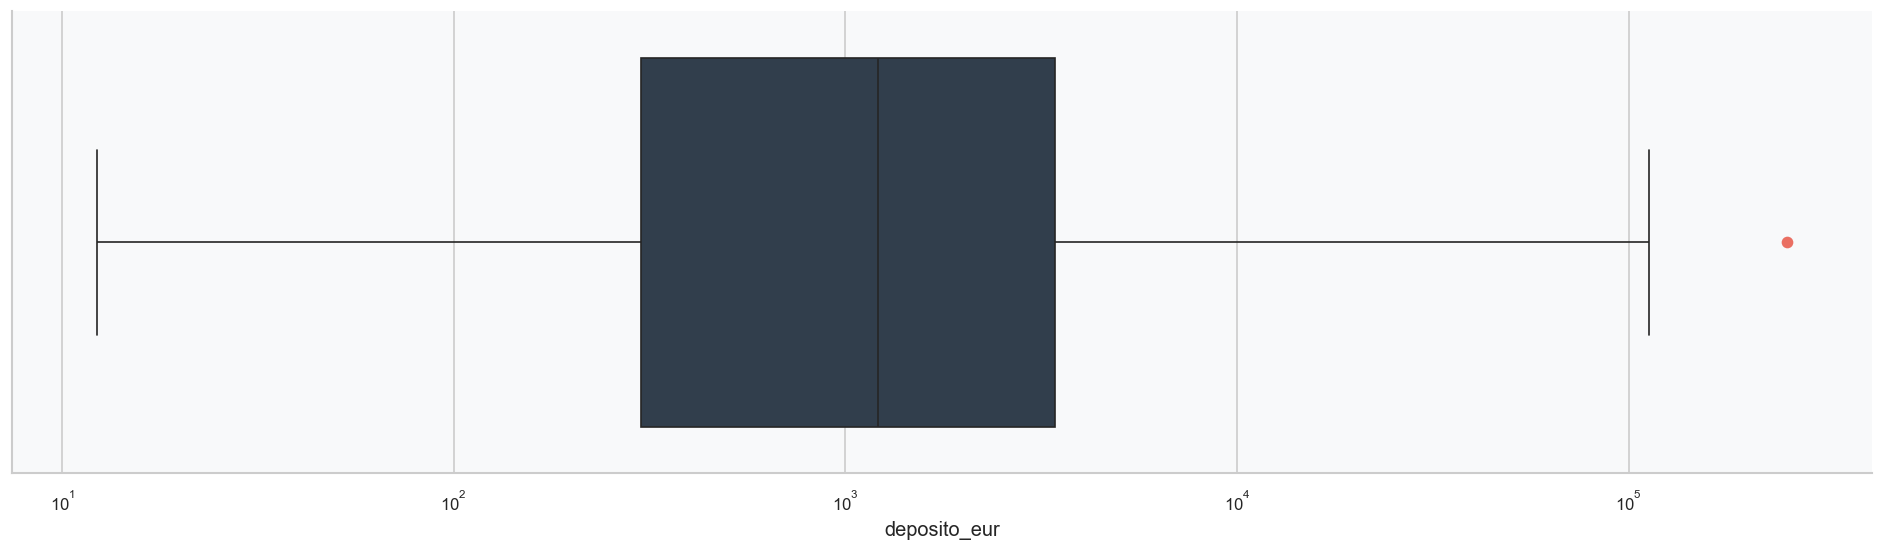

In [32]:
plt.figure(figsize=(20,5))
retornado = sns.boxplot(df_analisis["deposito_eur"], color= color_principal, orient= 'h', log_scale= True, flierprops= flierprops )

### duracion_dias
- Outliers interesantes: subastas muy cortas (1 día) y una muy larga (250 días)
- Las muy cortas pueden ser subastas canceladas rapidamente
- La muy larga es un caso excepcional

**Decisión:** Se conservan — son informativos

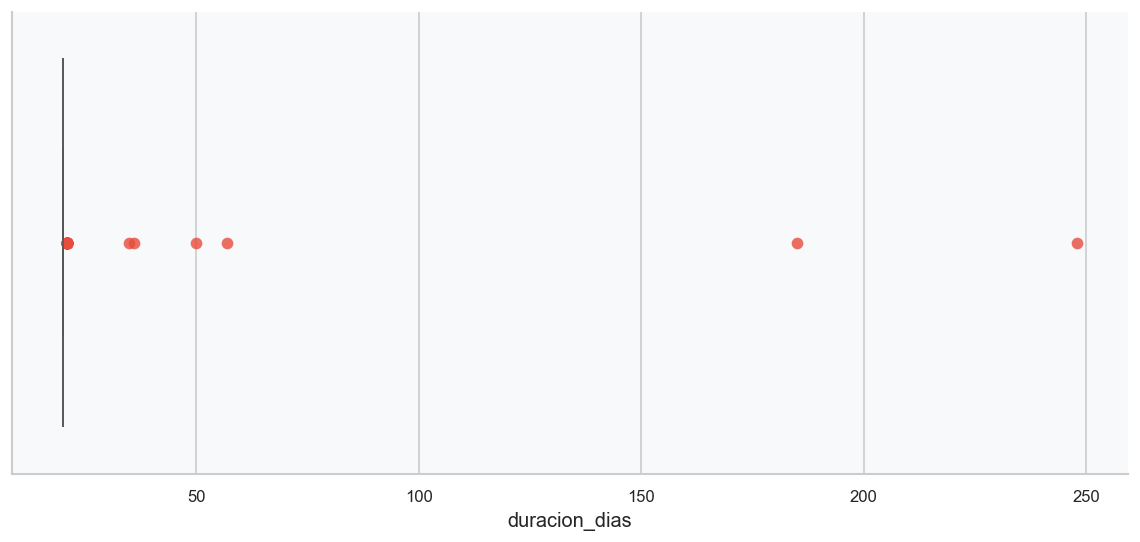

In [33]:
retornado = sns.boxplot(df_analisis["duracion_dias"], color= color_secundario, orient= 'h', flierprops = flierprops)

La gran mayoría de subastas duran exactamente **20 días**, lo cual corresponde al plazo legal establecido para subastas electrónicas en el Portal del BOE.
Las subastas de 21 días tuvieron una **prórroga automática** por recibir una puja en los últimos momentos antes del cierre.

Los outliers (185 y 248 días) corresponden a subastas con incidencias administrativas excepcionales.

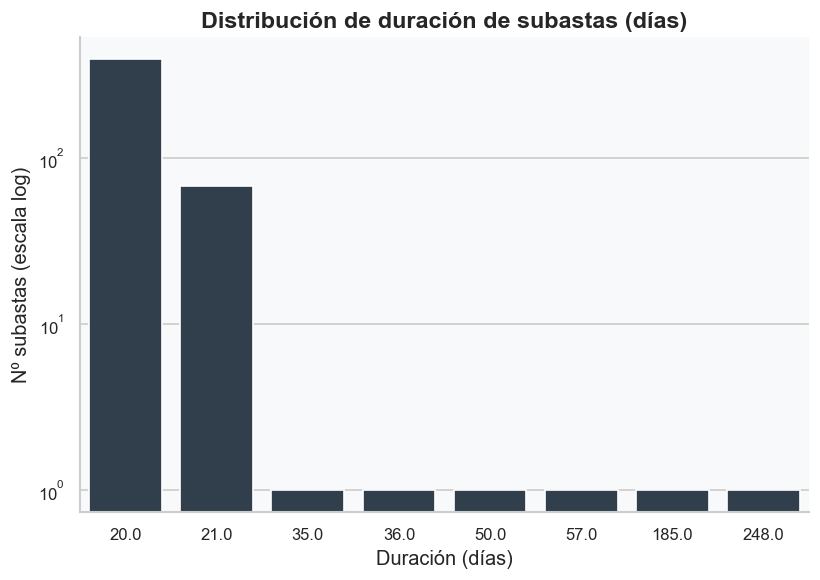

In [34]:
#===== Otra forma de verlos ====
plt.figure(figsize=(7,5))
sns.countplot(x = df_analisis["duracion_dias"], color= color_principal)
plt.yscale('log')
plt.title('Distribución de duración de subastas (días)')
plt.xlabel('Duración (días)')
plt.ylabel('Nº subastas (escala log)')
plt.tight_layout()

### Decisión global sobre Outliers

**Ningún outlier se elimina.** Para el análisis son informativos representan casos extremos reales que enriquecen el análisis y pueden ser las mejores oportunidades para inversores.

### **2. Análisis univariante**
Estudiar cada variable por separado para entender su distribución y estadísticas básicas.

In [35]:
# ====== Clasificar variables ============
card_tipo(df_analisis)

,Card,%_Card,Tipo,tipo_sugerido
referencia,498,100.0,str,Numerica continua
organismo,36,7.228916,str,Numerica discreta
estado,3,0.60241,str,Categorica
tipo_subasta,2,0.401606,str,Binaria
fecha_inicio,21,4.216867,datetime64[us],Numerica discreta
fecha_conclusion,37,7.429719,datetime64[us],Numerica discreta
lotes,1,0.0,int64,Categorica
valor_subasta_eur,390,78.313253,float64,Numerica continua
tasacion_eur,388,77.911647,float64,Numerica continua
puja_minima_eur,290,58.232932,float64,Numerica continua


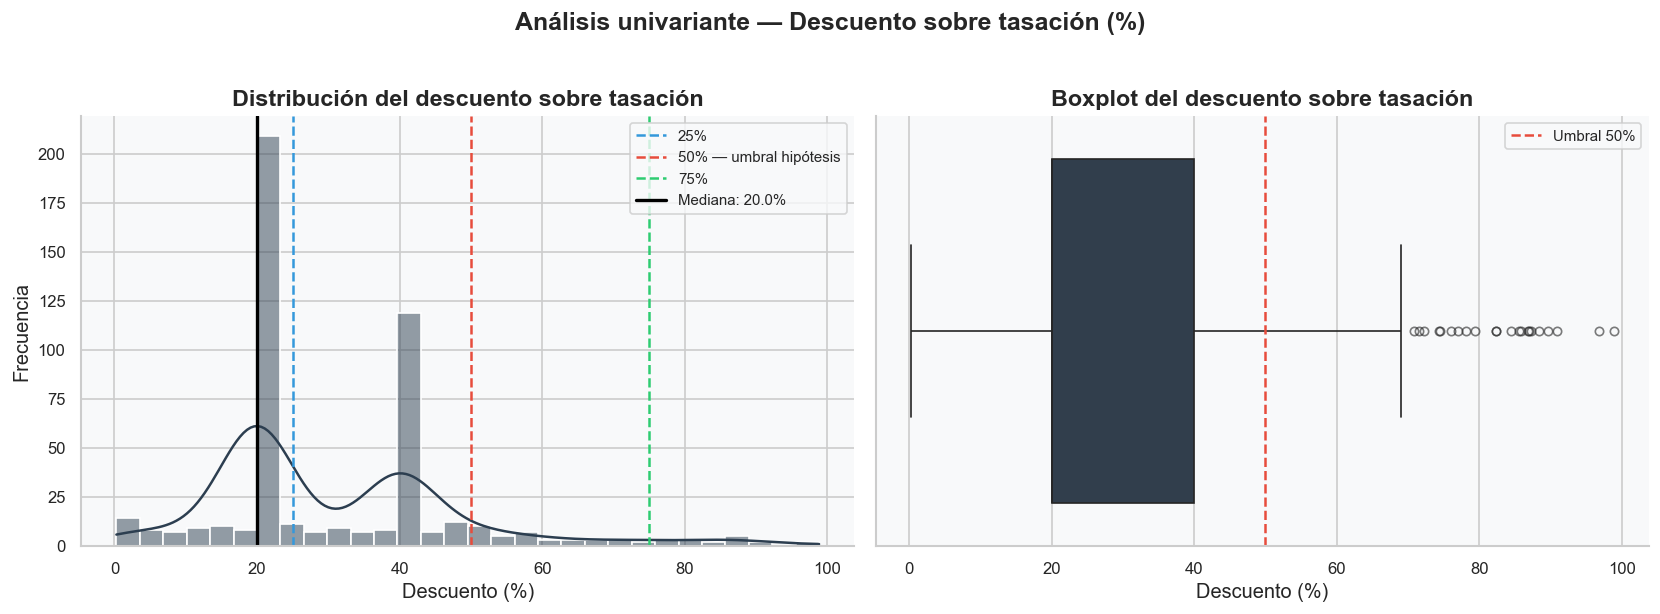

In [36]:
# ============ Distribucion del descuento_pct =============
plot_distribucion_descuento(df_analisis)

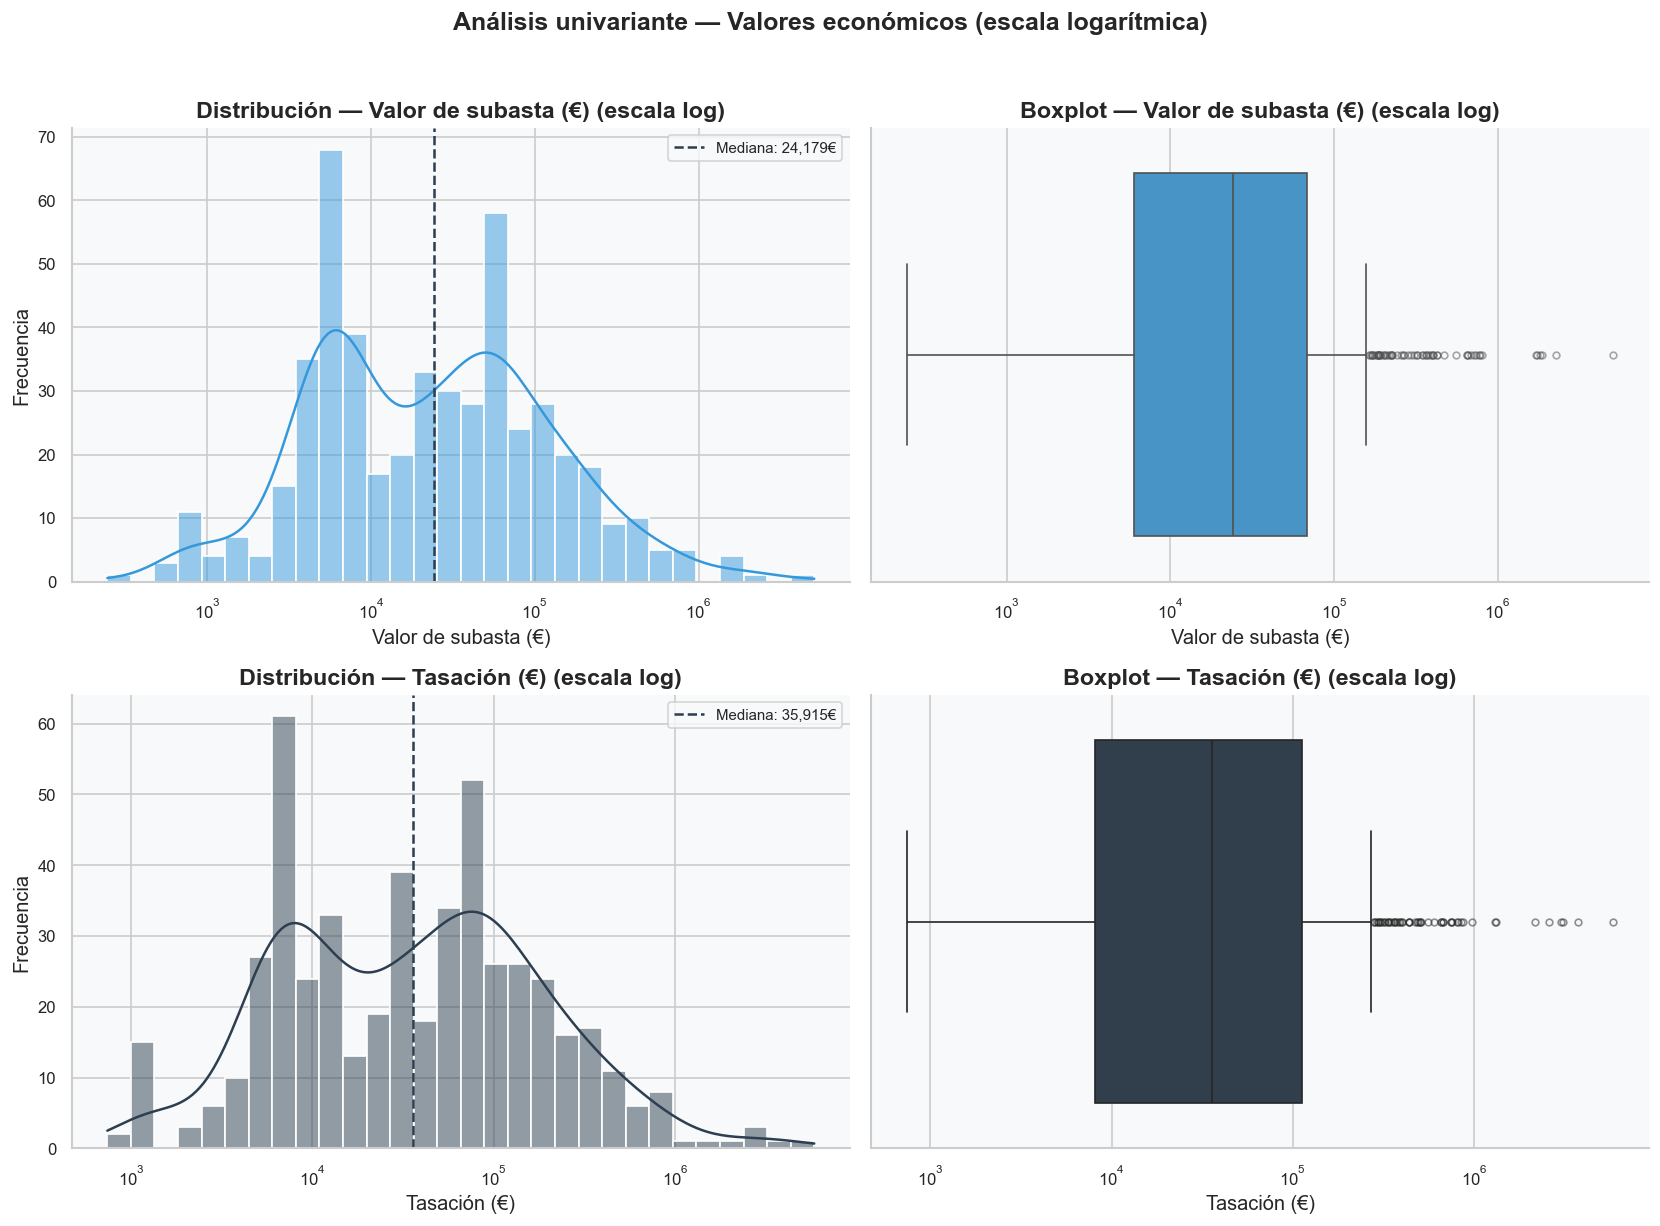

In [37]:
# =================== Distribución de valores económicos ======================
plot_distribucion_valores(df_analisis)

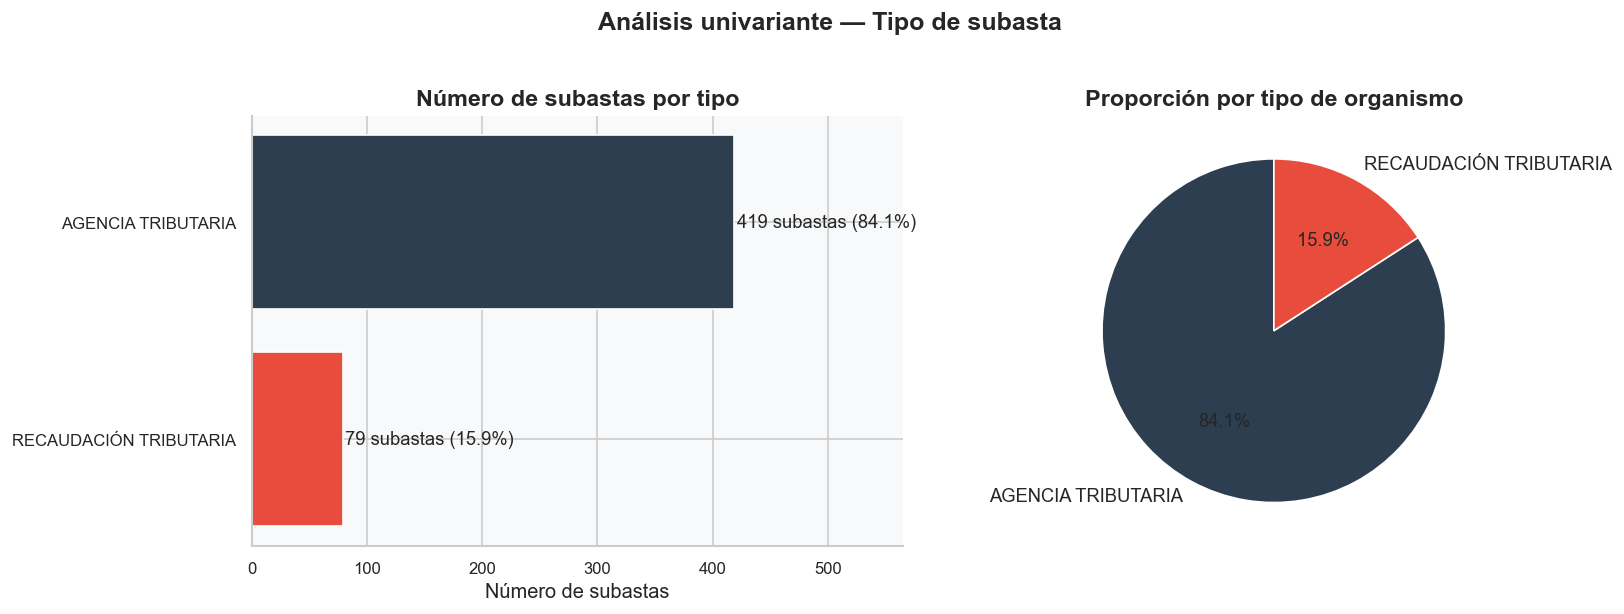

In [38]:
# Distribución de tipo_subasta
plot_tipo_subasta(df_analisis)

In [39]:
df_analisis.describe().round(2)

,fecha_inicio,fecha_conclusion,lotes,valor_subasta_eur,tasacion_eur,puja_minima_eur,tramo_pujas_eur,deposito_eur,descuento_pct,duracion_dias
count,470,470,498.0,498.00,498.00,397.00,498.00,498.00,498.00,470.00
mean,2025-10-19 13:19:39.574468,2025-11-09 17:52:20.425532,1.0,95749.97,138871.19,12444.13,994.46,4788.58,30.65,21.19
min,2025-03-11 00:00:00,2025-10-03 00:00:00,1.0,244.91,739.31,59.14,50.00,12.24,0.27,20.00
25%,2025-09-30 00:00:00,2025-10-20 00:00:00,1.0,6029.67,8152.14,570.97,212.50,301.48,20.00,20.00
50%,2025-10-21 00:00:00,2025-11-10 00:00:00,1.0,24179.06,35915.00,2100.35,500.00,1208.96,20.00,20.00
75%,2025-11-04 00:00:00,2025-11-29 12:00:00,1.0,68435.69,113065.20,7207.20,1502.36,3421.79,40.00,20.00
max,2025-12-09 00:00:00,2025-12-30 00:00:00,1.0,5089385.47,5878200.00,508938.55,10000.00,254469.27,98.84,248.00
std,NaN,NaN,0.0,312870.29,420773.04,38428.09,1044.44,15643.24,17.46,13.17


### **3. Análisis Multivariante**

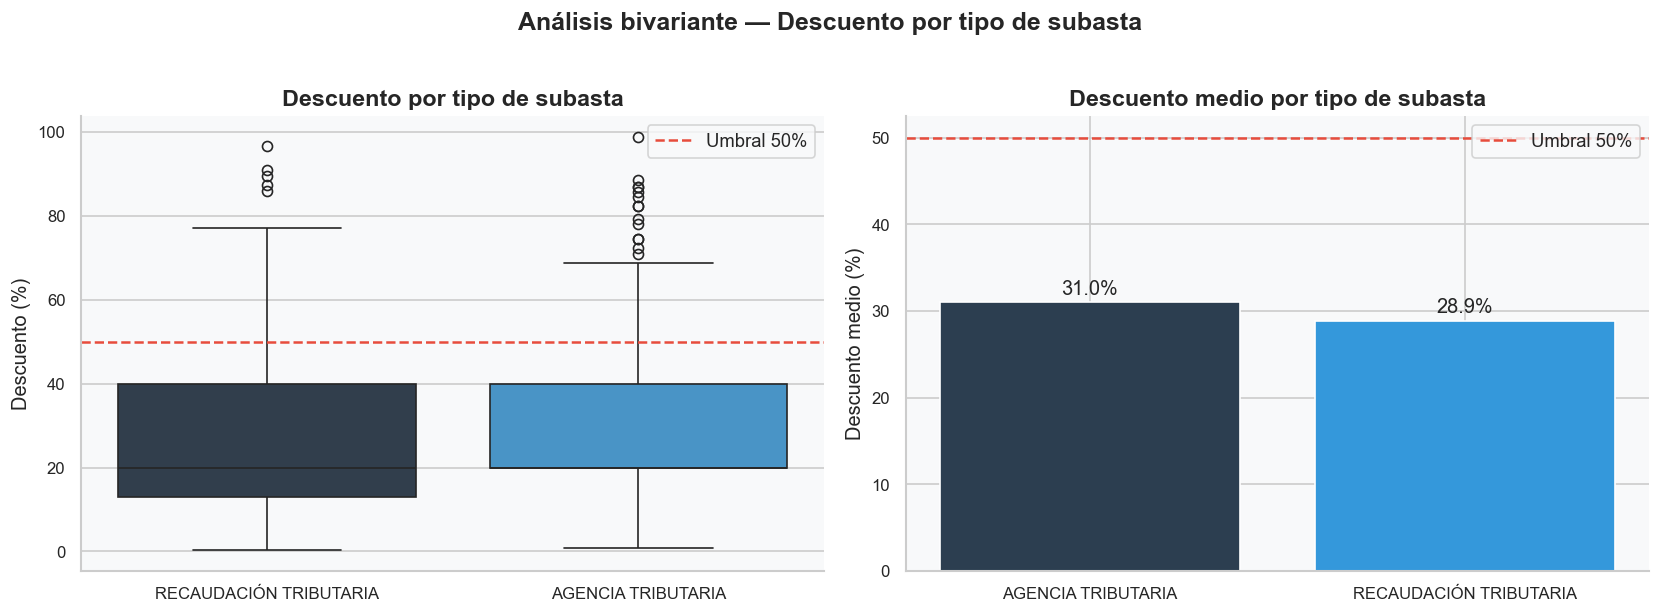

In [40]:
# 1. Descuento por tipo de subasta
plot_descuento_por_tipo(df_analisis)

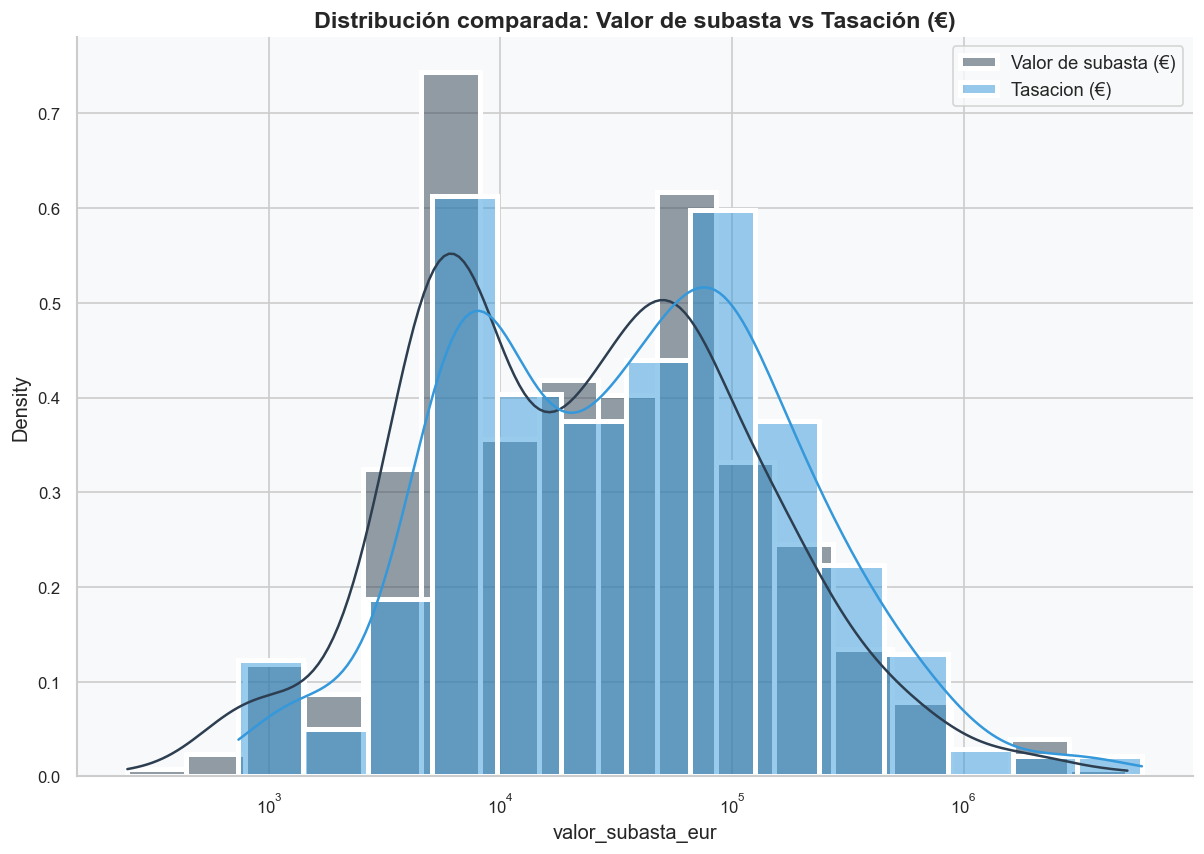

In [41]:
plt.figure(figsize=(12,8))
sns.histplot(df_analisis["valor_subasta_eur"] , color= color_principal, label="Valor de subasta (€)", kde=True, stat="density", linewidth=3, log_scale= True)
sns.histplot(df_analisis["tasacion_eur"] , color= color_acento, label="Tasacion (€)", kde=True, stat="density", linewidth=3, log_scale= True)
plt.title('Distribución comparada: Valor de subasta vs Tasación (€)')
plt.legend();

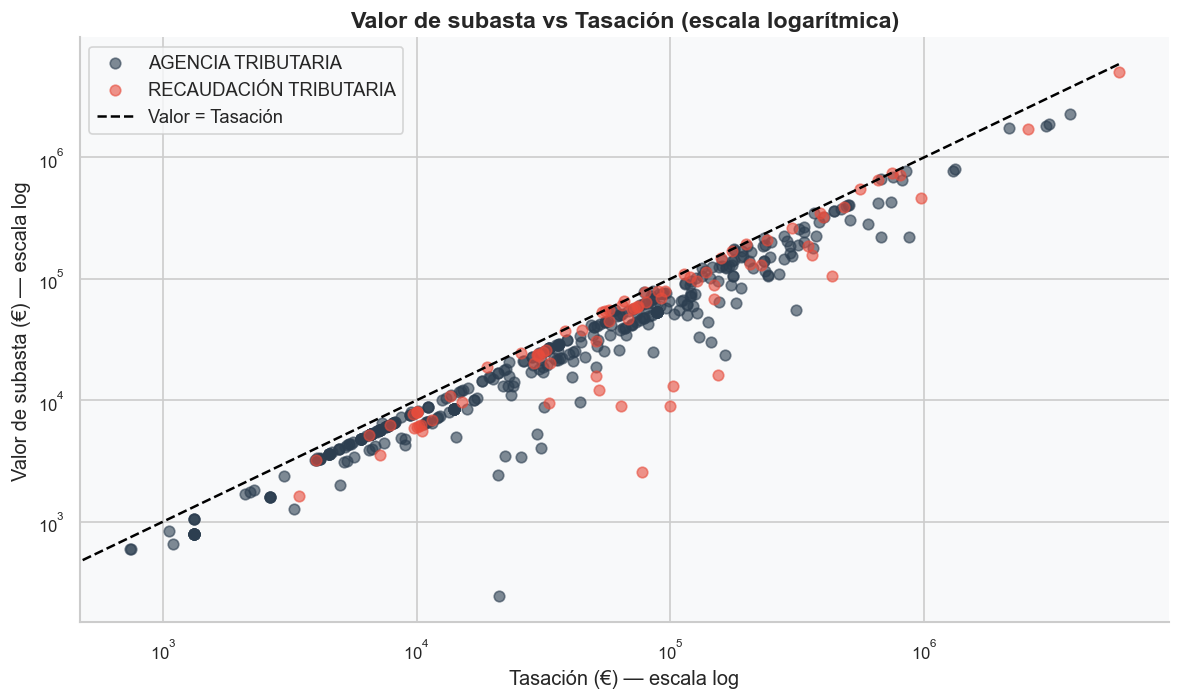

In [42]:
# 2. Valor subasta vs Tasación
plot_valor_vs_tasacion(df_analisis)

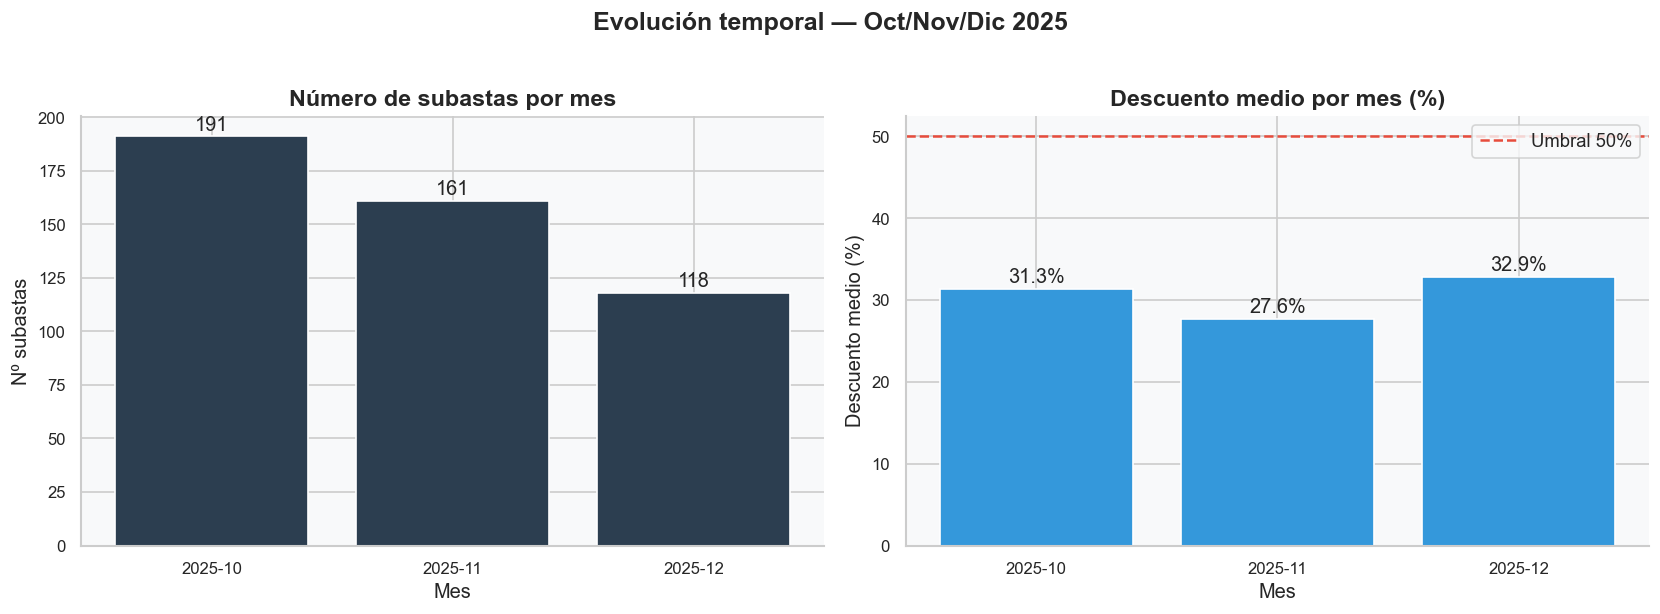

In [43]:
# 3. Evolución mensual
plot_evolucion_mensual(df_analisis)

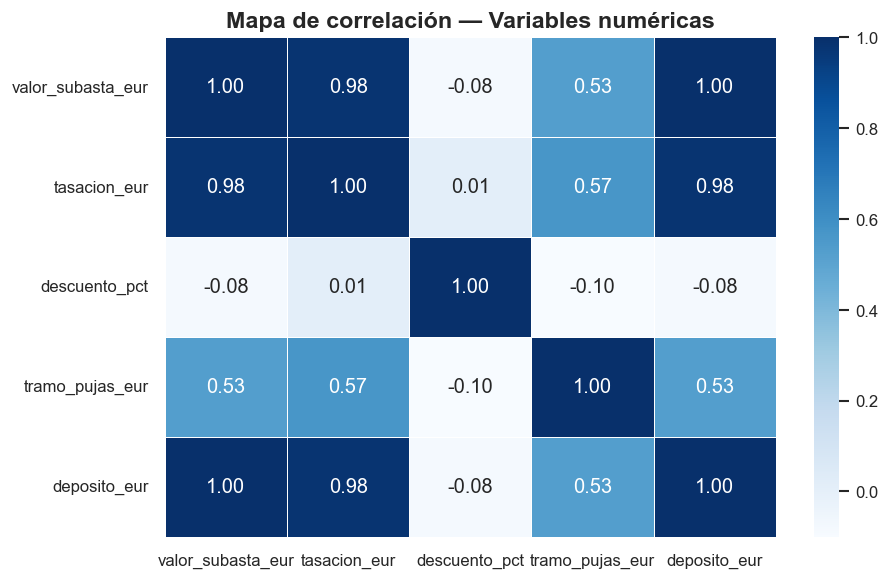

In [44]:
# Heatmap de correlación — relación entre todas las numéricas
cols_num = ['valor_subasta_eur', 'tasacion_eur', 'descuento_pct','tramo_pujas_eur', 'deposito_eur']

plt.figure(figsize=(8,5))
sns.heatmap(
    df_analisis[cols_num].corr().round(2),
    annot=True,
    cmap='Blues',
    fmt='.2f', #2 decimales
    linewidths=0.5,
    annot_kws= {'size': 12} #cambia el tamaño del texto de los números.
)
plt.title('Mapa de correlación — Variables numéricas')
plt.tight_layout()
plt.show()

### Correlaciones destacadas

**Correlación muy alta (≥ 0.98):**
- **valor_subasta_eur** <--> **tasacion_eur** = 0.98 : lógico, el valor de subasta se calcula como % de la tasación
- **valor_subasta_eur** <--> **deposito_eur** = 1.00 : el depósito es exactamente el 5% del valor de subasta (fórmula legal)

**Correlación media (0.53-0.57):**
- **tramo_pujas_eur** <--> **valor_subasta_eur** = 0.53 : a mayor valor de subasta, mayor incremento mínimo entre pujas

**Correlación casi nula con descuento_pct:**
- **descuento_pct** <--> **valor_subasta_eur** = -0.08
- **descuento_pct** <--> **tasacion_eur** = 0.01
- El descuento es independiente del valor del inmueble tanto inmuebles baratos como caros reciben descuentos similares

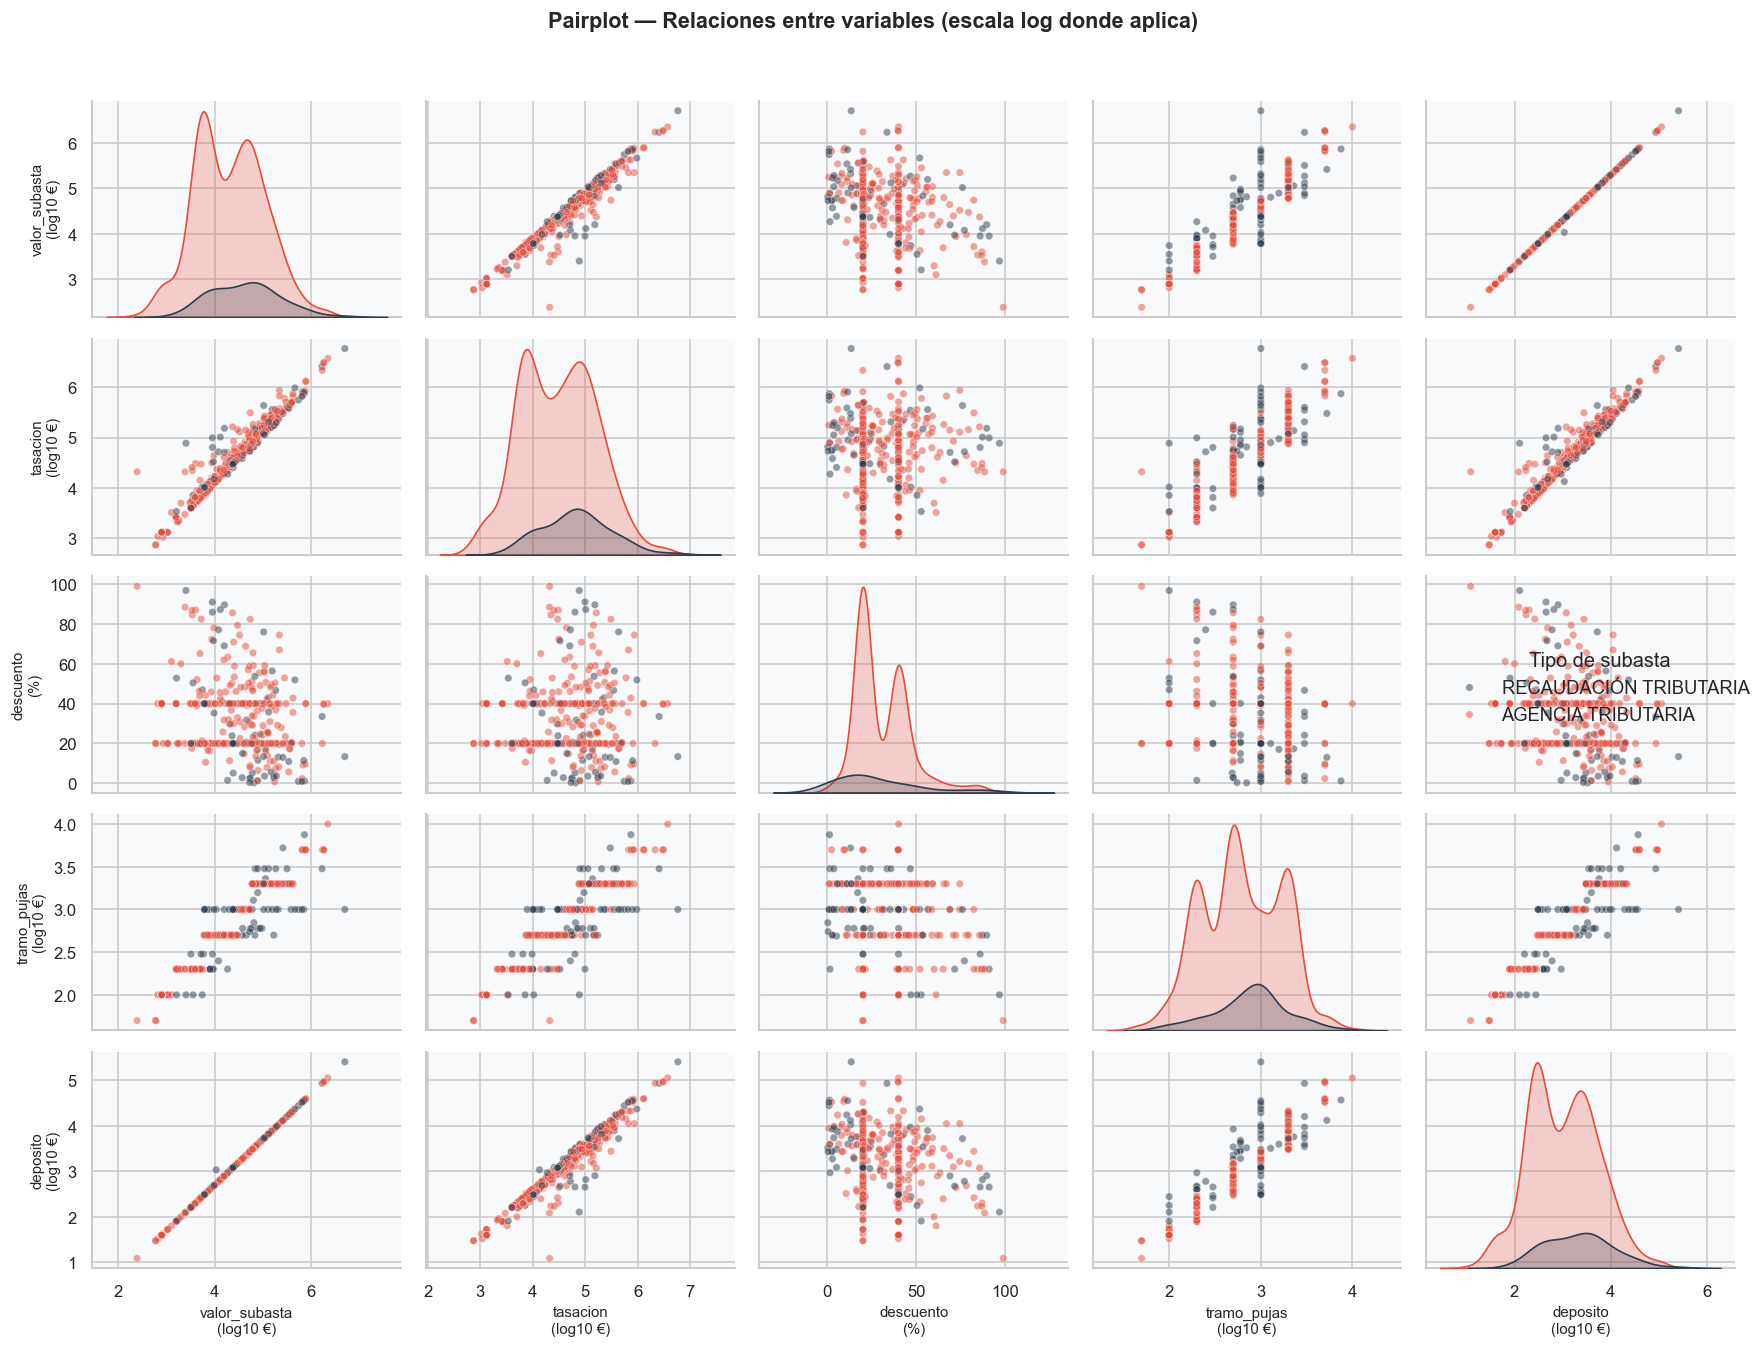

In [45]:
# ===== Pairplot — grid de relaciones entre variables ====
# Crear columnas en escala log para el pairplot
cols_num = ['valor_subasta_eur', 'tasacion_eur', 'descuento_pct','tramo_pujas_eur', 'deposito_eur']
df_plot = df_analisis[cols_num + ['tipo_subasta']].copy()
df_plot['valor_subasta_log']= np.log10(df_plot['valor_subasta_eur'])
df_plot['tasacion_log'] = np.log10(df_plot['tasacion_eur'])
df_plot['tramo_pujas_log'] = np.log10(df_plot['tramo_pujas_eur'])
df_plot['deposito_log'] = np.log10(df_plot['deposito_eur'])

# Columnas a usar en el pairplot
cols_plot = [
    'valor_subasta_log','tasacion_log','descuento_pct', # descuento_pct NO esta en log es %
    'tramo_pujas_log','deposito_log','tipo_subasta'
]

g = sns.pairplot(
    df_plot[cols_plot],
    hue='tipo_subasta',
    palette=[color_principal, color_secundario],
    plot_kws={'alpha': 0.5, 's': 20},
    height=2.2,          # ← tamaño de cada celda
    aspect=1.1
)

# Mover leyenda dentro del gráfico
g.legend.set_bbox_to_anchor((1.0, 0.5))
g.legend.set_title('Tipo de subasta')

# Renombrar ejes para que se lean bien
nuevos_nombres = {
    'valor_subasta_log': 'valor_subasta\n(log10 €)',
    'tasacion_log': 'tasacion\n(log10 €)',
    'descuento_pct': 'descuento\n(%)',
    'tramo_pujas_log': 'tramo_pujas\n(log10 €)',
    'deposito_log': 'deposito\n(log10 €)',
}
for ax in g.axes.flatten():
    if ax:
        xlabel = ax.get_xlabel()
        ylabel = ax.get_ylabel()
        if xlabel in nuevos_nombres:
            ax.set_xlabel(nuevos_nombres[xlabel], fontsize=9)
        if ylabel in nuevos_nombres:
            ax.set_ylabel(nuevos_nombres[ylabel], fontsize=9)

g.figure.suptitle(
    'Pairplot — Relaciones entre variables (escala log donde aplica)',
    y=1.02, fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

**valor_subasta vs tasacion (log):**
- Relación lineal confirma la correlación 0.98
- Ambos tipos de subasta siguen el mismo patrón

**descuento_pct vs cualquier variable:**
- Nube de puntos sin patrón claro que confirma independencia
- Los dos picos verticales (20% y 40%) se ven claramente
- No hay diferencia visual entre AEAT y Recaudación

**valor_subasta vs deposito (log):**
- Línea diagonal perfecta con eso se confirma que depósito = 5% valor de subasta
- Todos los puntos están alineados

**tramo_pujas — patrón discreto:**
- Los puntos forman líneas horizontales, valores estandarizados
- La AEAT usa tramos fijos (500€, 1000€, 2000€...)

In [46]:
print('Valores únicos de lotes:')
print(df_analisis['lotes'].value_counts())

print('\nValores únicos de estado:')
print(df_analisis['estado'].value_counts())

print('\nValores únicos de duracion_dias:')
print(df_analisis['duracion_dias'].value_counts())

Valores únicos de lotes:
lotes
1    498
Name: count, dtype: int64

Valores únicos de estado:
estado
Finalizada y depósitos con reserva devueltos                       462
Cancelada                                                           28
Pendiente de finalización y devolución de depósitos con reserva      8
Name: count, dtype: int64

Valores únicos de duracion_dias:
duracion_dias
20.0     396
21.0      68
185.0      1
36.0       1
50.0       1
248.0      1
35.0       1
57.0       1
Name: count, dtype: int64


## **6. Contraste de Hipótesis**

**Hipótesis planteada:**
> "Las subastas de inmuebles de organismos tributarios (AEAT y Recaudación Tributaria) en España entre octubre y diciembre 2025 se ofertan mayoritariamente por debajo del 50% de su valor de tasación"

Para contrastarla analizamos qué porcentaje de subastas tiene un descuento menor al 50%.

In [47]:
total      = len(df_analisis)
bajo_50    = (df_analisis['descuento_pct'] < 50).sum()
sobre_50   = (df_analisis['descuento_pct'] >= 50).sum()
pct_bajo   = bajo_50 / total * 100
pct_sobre  = sobre_50 / total * 100

print('===== CONTRASTE DE HIPÓTESIS =====')
print('==================================')
print(f'Total subastas analizadas: {total}')
print(f'Con descuento < 50% : {bajo_50} ({pct_bajo:.1f}%)')
print(f'Con descuento >= 50% : {sobre_50} ({pct_sobre:.1f}%)')
print(f'\n  Descuento medio: {df_analisis["descuento_pct"].mean():.1f}%')
print(f'  Descuento mediana: {df_analisis["descuento_pct"].median():.1f}%')
print(f'\n  ¿Se cumple la hipótesis?')
if pct_bajo > 50:
    print(f'SÍ — el {pct_bajo:.1f}% de subastas está por debajo del 50%')
else:
    print(f'NO — solo el {pct_bajo:.1f}% está por debajo del 50%')
print('=' * 45)

===== CONTRASTE DE HIPÓTESIS =====
Total subastas analizadas: 498
Con descuento < 50% : 445 (89.4%)
Con descuento >= 50% : 53 (10.6%)

  Descuento medio: 30.7%
  Descuento mediana: 20.0%

  ¿Se cumple la hipótesis?
SÍ — el 89.4% de subastas está por debajo del 50%


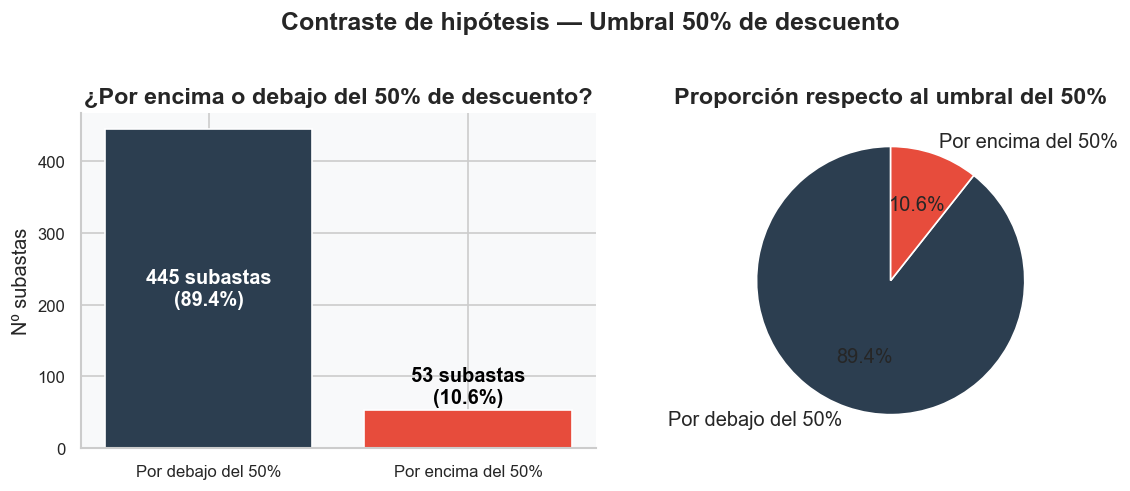

In [48]:
plot_contraste_hipotesis(df_analisis)

In [49]:
print('=== CONTRASTE POR TIPO DE SUBASTA ===\n')
for tipo in df_analisis['tipo_subasta'].unique():
    subset = df_analisis[df_analisis['tipo_subasta'] == tipo]
    bajo   = (subset['descuento_pct'] < 50).sum()
    total_t = len(subset)
    print(f'{tipo}:')
    print(f'  Total          : {total_t}')
    print(f'  Bajo 50%       : {bajo} ({bajo/total_t*100:.1f}%)')
    print(f'  Descuento medio: {subset["descuento_pct"].mean():.1f}%')
    print()

=== CONTRASTE POR TIPO DE SUBASTA ===

RECAUDACIÓN TRIBUTARIA:
  Total          : 79
  Bajo 50%       : 65 (82.3%)
  Descuento medio: 28.9%

AGENCIA TRIBUTARIA:
  Total          : 419
  Bajo 50%       : 380 (90.7%)
  Descuento medio: 31.0%



### **6.1 Resultado del contraste**

### La hipótesis SE CUMPLE

| | Total | Bajo 50% | Porcentaje |
|--|-------|---------|-----------|
| **AGENCIA TRIBUTARIA** | 419 | 380 | **90.7%** |
| **RECAUDACIÓN TRIBUTARIA** | 79 | 65 | **82.3%** |
| **TOTAL** | 498 | 445 | **89.4%** |

**El 89.4% de los inmuebles subastados por organismos tributarios entre octubre y diciembre 2025 se ofertan por debajo del 50% de su valor de tasación.**

El descuento medio es del **30.65%** sobre la tasación, con una mediana de **20%** que corresponde al descuento legal estándar aplicado por la AEAT.

### Insights adicionales
- La AEAT aplica descuentos más consistentes (90.7% bajo el umbral)
- Recaudación Tributaria tiene mayor variabilidad (82.3%)
- Solo 53 subastas (10.6%) superan el 50% de descuento — 
  estas representan las **mejores oportunidades para inversores**
  pero también las de **mayor riesgo por cargas registrales**

### **7. Conclusiones**

### 7.1 Respuesta a la hipótesis
**La hipótesis se confirma.**

El 89.4% de los inmuebles subastados por organismos tributarios en España (oct-dic 2025) se ofertan por debajo del 50% de su valor de tasación muy por encima del umbral planteado.

---

### 7.2 Hallazgos principales

**1. El descuento estándar es del 20%**
La AEAT aplica por ley un descuento fijo del 20% sobre la tasación como precio de salida. Esto explica los dos picos en la distribución (20% y 40% para subastas con descuento  adicional por cargas).

**2. El depósito siempre es el 5% del valor de subasta**
Correlación perfecta (1.00) entre **deposito_eur** y **valor_subasta_eur** la ley establece este porcentaje de forma inamovible.

**3. El descuento es independiente del valor del inmueble**
Correlación casi nula (-0.08) entre **descuento_pct** y **valor_subasta_eur** tanto inmuebles baratos como caros reciben descuentos similares.

**4. La AEAT domina el mercado de subastas tributarias**
El 84.1% de las subastas analizadas corresponden a la AEAT vs 15.9% de Recaudación Tributaria.

**5. Las subastas duran exactamente 20 días**
El 84.3% duran exactamente 20 días — plazo legal establecido. Las de 21 días tuvieron prórroga automática por puja en el último momento.

**6. El inmueble típico subastado**
- Valor de tasación mediano: **35.915€**
- Valor de subasta mediano: **24.179€**
- Descuento mediano: **20%**
- Duración: **20 días**

---

### 7.3 Oportunidades para inversores

Las 53 subastas con descuento superior al 50% representan las mejores oportunidades económicas, pero también las de mayor riesgo:

**Advertencia importante:**
Un descuento alto no siempre significa una oportunidad real. Puede indicar cargas registrales elevadas que el comprador debe asumir. Antes de pujar es fundamental revisar la 
Certificación de Cargas disponible en cada ficha del portal.

---

### 7.4 Limitaciones del análisis

- Solo se analizaron subastas de organismos tributarios (AEAT y Recaudación) el 84.5% del dataset total fue descartado por datos incompletos en el portal
- Período limitado a 3 meses (oct-dic 2025)
- No se dispone de datos sobre el resultado final de las pujas ni el precio de adjudicación
- Las subastas con varios lotes no pudieron analizarse individualmente

---

### 7.5 Plan de acción

Para un inversor interesado en subastas del BOE:

1. **Filtrar** por organismos tributarios — datos más fiables
2. **Revisar** siempre la Certificación de Cargas antes de pujar
3. **Vigilar** subastas con descuento > 50% — mayor oportunidad   pero mayor due diligence necesario
4. **Monitorizar** el portal diariamente — las mejores subastas 
   se publican durante todo el mes

### **8. Guardar dataset final**

In [50]:
df_analisis.to_csv(
    './data/subastas_analisis_final.csv',
    index=False,
    encoding='utf-8-sig'
)
print(f'Dataset final guardado')
print(f'Registros : {len(df_analisis)}')
print(f'Columnas  : {df_analisis.shape[1]}')

Dataset final guardado
Registros : 498
Columnas  : 14
